# SHAP Cluster Inspection
This notebook inspects one exported clustering candidate at a time, recreates the SHAP cluster-profile views, and visualizes trajectory- and scene-level distributions for the selected subsets without reloading `trajdata`.


In [11]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from data_modelling.shap_cluster_inspection import (
    WHOLE_GROUP_LABEL,
    build_cluster_inspection_export_layout,
    build_distribution_subset_frames,
    build_subset_style_map,
    build_subset_summary_table,
    build_top_driver_table,
    load_cluster_inspection_selection,
    plot_candidate_umap_scatter,
    plot_cluster_profile_barplots,
    plot_cluster_profile_heatmap,
    plot_metric_distribution_panels,
    plot_metric_overview_matrix_pages,
    resolve_cluster_inspection_config,
)
from data_modelling.shap_performance_regimes_utils import get_shap_cols

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

INSPECTION_CONFIG = {
    'cluster_spec_manifest_path': '../../results/interpretable_model/shap_performance_regimes/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/manifest.json',
    'performance_group': 'hard',
    'inspection_algorithm': 'hdbscan',
    'inspection_cluster_space': 'raw',
    'cluster_ids': 'all',
    'inspection_top_k_features': 8,
    'inspection_top_k_table': 3,
    'distribution_matrix_max_columns': 8,
    # Kept for continuity with the earlier workflow; subset display order stays size-first.
    'sort_cluster_profiles_by': 'cluster_size',
}

def slugify_token(value: object) -> str:
    text = str(value).strip().lower()
    text = re.sub(r'[^a-z0-9._-]+', '-', text)
    text = re.sub(r'-{2,}', '-', text)
    return text.strip('-') or 'na'

def cluster_display_label(cluster_id: int) -> str:
    return 'Noise' if int(cluster_id) == -1 else f'Cluster {int(cluster_id)}'


## Resolve Inspection Context
**Purpose:** Validate the requested candidate selection, load the exported cluster tables, and prepare deterministic output folders for the prettier per-feature plots and overview matrices.<br>
**Inputs:** `INSPECTION_CONFIG` and the cluster-spec `manifest.json` produced by the export-first clustering notebook.<br>
**Outputs:** `resolved_inspection_config`, `inspection_bundle`, `subset_style_map`, the ordered feature lists, and the candidate-specific output directories used for this inspection run.<br>
**How to Verify:** Confirm the printed manifest path, selected candidate tuple, ordered cluster ids, ordered feature lists, and inspection output folders before reviewing plots.


In [12]:
resolved_inspection_config = resolve_cluster_inspection_config(INSPECTION_CONFIG)
inspection_bundle = load_cluster_inspection_selection(resolved_inspection_config)
INSPECTION_LAYOUT = build_cluster_inspection_export_layout(
    inspection_bundle.cluster_spec_root,
    performance_group=inspection_bundle.performance_group,
    algorithm=inspection_bundle.algorithm,
    cluster_space=inspection_bundle.cluster_space,
    cluster_ids=resolved_inspection_config['cluster_ids'],
)
PLOTS_DIR = INSPECTION_LAYOUT['plots_dir']
TRAJECTORY_DISTRIBUTION_DIR = PLOTS_DIR / 'trajectory_feature_distributions'
SCENE_DISTRIBUTION_DIR = PLOTS_DIR / 'scene_metric_distributions'
TRAJECTORY_OVERVIEW_DIR = PLOTS_DIR / 'trajectory_feature_overview'
SCENE_OVERVIEW_DIR = PLOTS_DIR / 'scene_metric_overview'
for output_dir in [
    TRAJECTORY_DISTRIBUTION_DIR,
    SCENE_DISTRIBUTION_DIR,
    TRAJECTORY_OVERVIEW_DIR,
    SCENE_OVERVIEW_DIR,
]:
    output_dir.mkdir(parents=True, exist_ok=True)

selected_shap_cols = get_shap_cols(inspection_bundle.selected_profiles_df)
selected_subset_labels = [cluster_display_label(cluster_id) for cluster_id in inspection_bundle.ordered_cluster_ids]
subset_style_map = build_subset_style_map(selected_subset_labels + [WHOLE_GROUP_LABEL])

print(f"Manifest: {inspection_bundle.manifest_path}")
print(
    'Selected candidate: '
    f"group={inspection_bundle.performance_group}, "
    f"algorithm={inspection_bundle.algorithm}, "
    f"cluster_space={inspection_bundle.cluster_space}"
)
print(f"Ordered cluster ids: {inspection_bundle.ordered_cluster_ids}")
print(f"Inspection output root: {INSPECTION_LAYOUT['selection_root']}")
print(f"Ordered trajectory features ({len(inspection_bundle.trajectory_feature_cols)}): {inspection_bundle.trajectory_feature_cols}")
print(f"Ordered scene metrics ({len(inspection_bundle.scene_metric_cols)}): {inspection_bundle.scene_metric_cols}")
print(f"Matrix max columns: {resolved_inspection_config['distribution_matrix_max_columns']}")


Manifest: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/shap_performance_regimes/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/manifest.json
Selected candidate: group=hard, algorithm=hdbscan, cluster_space=raw
Ordered cluster ids: [1, 3, 0, 2, -1]
Inspection output root: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/shap_performance_regimes/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__space-raw__selection-all
Ordered trajectory features (7): ['std_speed', 'head

## Review Exported Subsets
**Purpose:** Surface the selected subset metadata and the member-file locations before plotting cluster-level behavior.<br>
**Inputs:** `inspection_bundle.selected_catalog_df`, `inspection_bundle.selected_profiles_df`, and the resolved inspection config.<br>
**Outputs:** Compact subset summaries, top-driver tables, and a quick view of the exported member-file paths used to bridge back to individual trajectories.<br>
**How to Verify:** Check that the subset sizes, noise presence, and member-file paths match the candidate you expect to inspect.


In [13]:
subset_summary_df = build_subset_summary_table(inspection_bundle.selected_catalog_df)
top_driver_table_df = build_top_driver_table(
    inspection_bundle.selected_profiles_df,
    shap_cols=selected_shap_cols,
    top_k_table=resolved_inspection_config['inspection_top_k_table'],
)
member_catalog_view = inspection_bundle.selected_catalog_df[
    [
        'cluster_id',
        'cluster_label',
        'is_noise',
        'cluster_size',
        'cluster_size_share',
        'members_relative_path',
    ]
].copy()

display(subset_summary_df)
display(top_driver_table_df)
display(member_catalog_view)


,cluster_id,is_noise,cluster_size,cluster_size_share,unique_scene_step_count,unique_scene_count
0,1,False,34,0.300885,19,2
1,3,False,32,0.283186,13,2
2,0,False,10,0.088496,10,1
3,2,False,6,0.053097,6,2
4,-1,True,31,0.274336,22,2


,cluster_id,cluster_label,is_noise,cluster_size,cluster_size_share,top_feature_1,top_direction_1,top_abs_shap_1,top_feature_2,top_direction_2,top_abs_shap_2,top_feature_3,top_direction_3,top_abs_shap_3
0,1,Cluster 1,False,34,0.300885,max_speed,positive,0.108240,min_neighbor_distance,positive,0.047354,mean_acceleration,positive,0.043583
1,3,Cluster 3,False,32,0.283186,heading_change,positive,0.152190,max_speed,positive,0.091921,std_speed,positive,0.081644
2,0,Cluster 0,False,10,0.088496,std_speed,positive,0.297476,heading_change,positive,0.139066,max_speed,positive,0.081132
3,2,Cluster 2,False,6,0.053097,std_speed,positive,0.139392,heading_change,positive,0.095028,scene_spatial_density,negative,0.060338
4,-1,Noise,True,31,0.274336,std_speed,positive,0.207072,heading_change,positive,0.107109,max_speed,positive,0.081375


,cluster_id,cluster_label,is_noise,cluster_size,cluster_size_share,members_relative_path
0,1,cluster_1,False,34,0.300885,tables/cluster_members__group-hard__alg-hdbsca...
1,3,cluster_3,False,32,0.283186,tables/cluster_members__group-hard__alg-hdbsca...
2,0,cluster_0,False,10,0.088496,tables/cluster_members__group-hard__alg-hdbsca...
3,2,cluster_2,False,6,0.053097,tables/cluster_members__group-hard__alg-hdbsca...
4,-1,noise,True,31,0.274336,tables/cluster_members__group-hard__alg-hdbsca...


## Plot Candidate UMAP Scatter
**Purpose:** Recreate the candidate-level cluster map in the stored visualization UMAP space so the selected subsets can be inspected spatially.<br>
**Inputs:** `inspection_bundle.group_assignments_df`, stored `viz_umap_x/y`, the selected candidate label column, and the shared subset color map.<br>
**Outputs:** One saved UMAP scatter plot for the inspected candidate, with noise shown distinctly when present.<br>
**How to Verify:** Confirm the legend labels and point counts match the selected subset summary table and that cluster colors stay consistent with the later inspection plots.


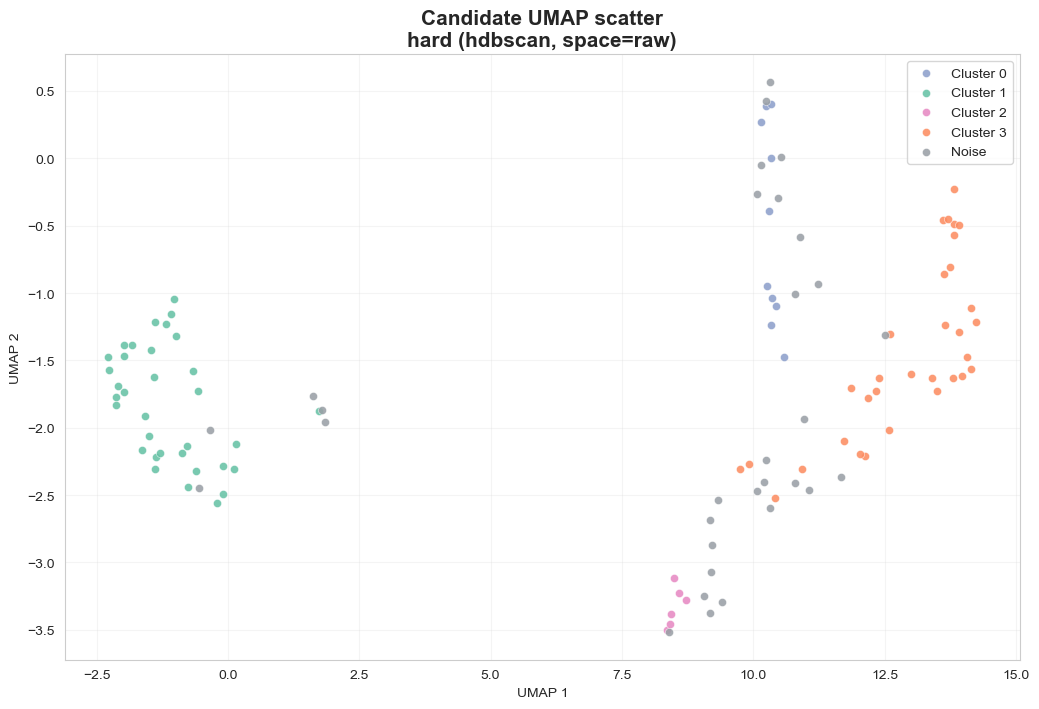

Candidate UMAP scatter saved to: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/shap_performance_regimes/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__space-raw__selection-all/plots/candidate_umap_scatter__group-hard__alg-hdbscan__space-raw.png


In [14]:
umap_scatter_path = PLOTS_DIR / (
    'candidate_umap_scatter__'
    f"group-{slugify_token(inspection_bundle.performance_group)}__"
    f"alg-{slugify_token(inspection_bundle.algorithm)}__"
    f"space-{slugify_token(inspection_bundle.cluster_space)}.png"
)
plot_candidate_umap_scatter(
    inspection_bundle.group_assignments_df,
    candidate_label_col=inspection_bundle.candidate_label_col,
    performance_group=inspection_bundle.performance_group,
    algorithm=inspection_bundle.algorithm,
    cluster_space=inspection_bundle.cluster_space,
    plot_path=umap_scatter_path,
    subset_style_map=subset_style_map,
)
print(f'Candidate UMAP scatter saved to: {umap_scatter_path}')


## Plot SHAP Cluster Profiles
**Purpose:** Recreate the signed SHAP inspection views for the selected subsets in the requested candidate run with the shared subset styling.<br>
**Inputs:** `inspection_bundle.selected_profiles_df`, `selected_shap_cols`, the SHAP inspection controls from `INSPECTION_CONFIG`, and `subset_style_map`.<br>
**Outputs:** One saved signed-barplot figure and one SHAP heatmap over the selected subsets.<br>
**How to Verify:** Confirm the subset order is non-noise clusters by size followed by noise when requested and that the styling stays aligned with the UMAP view.


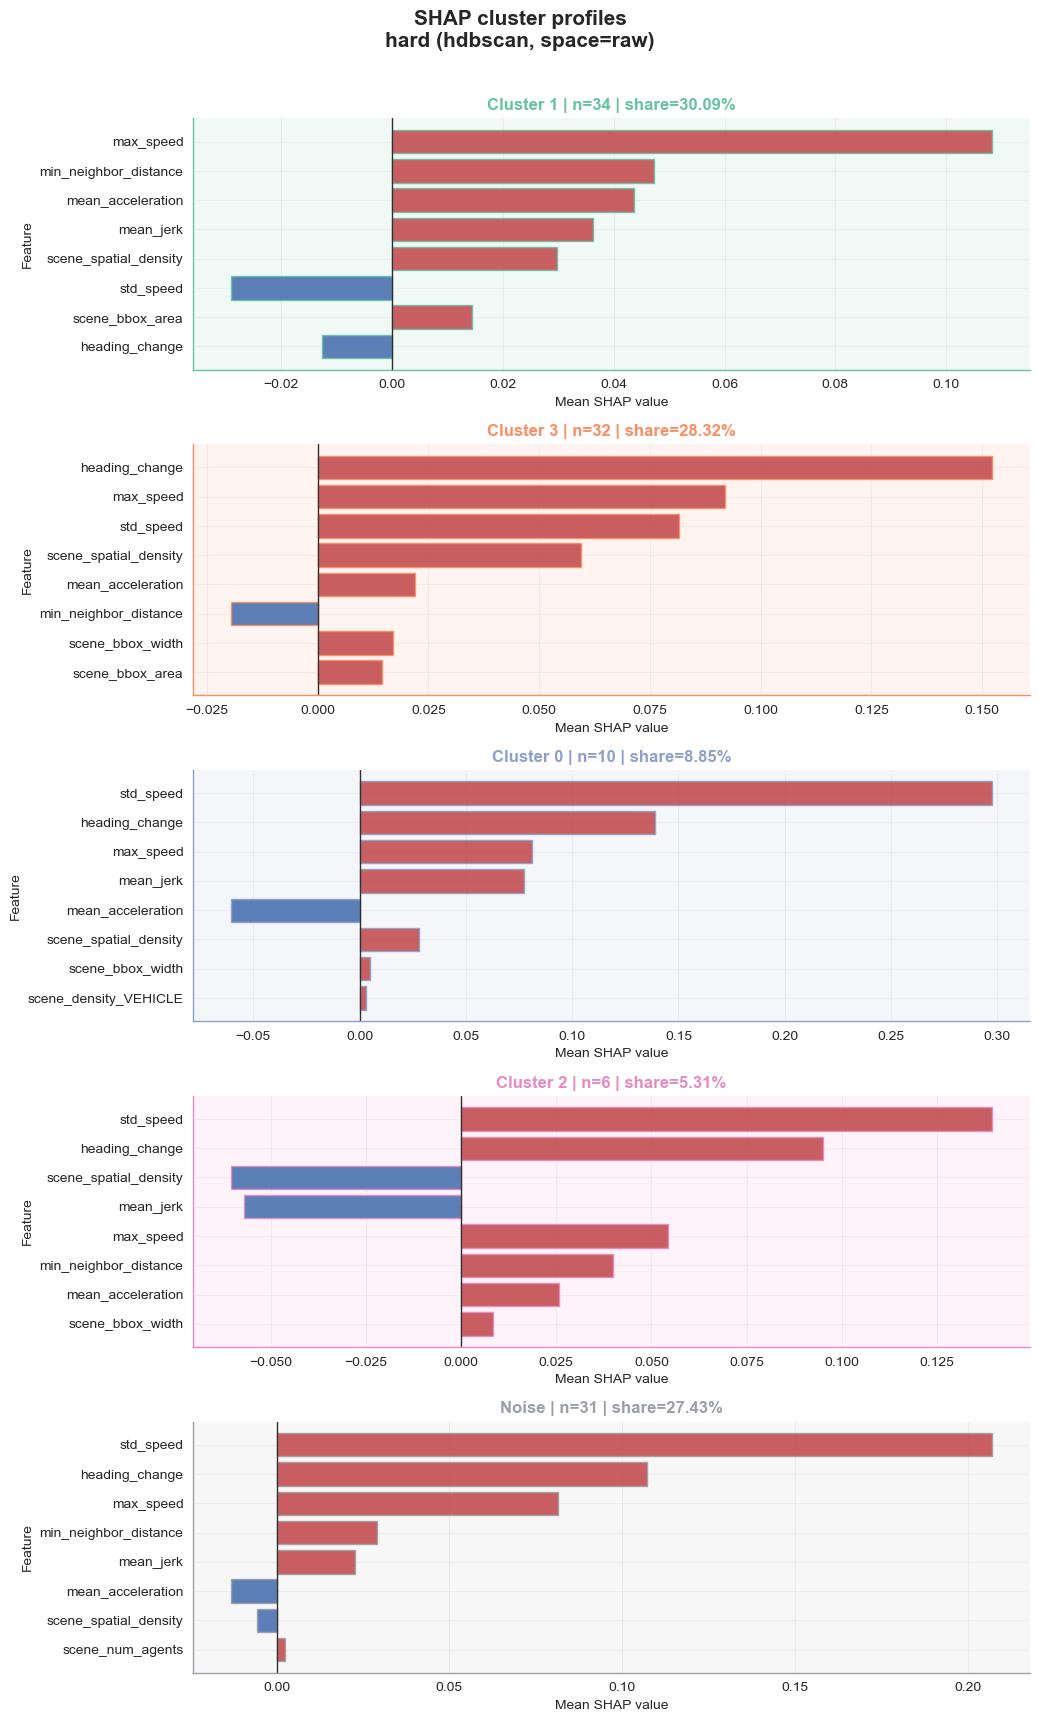

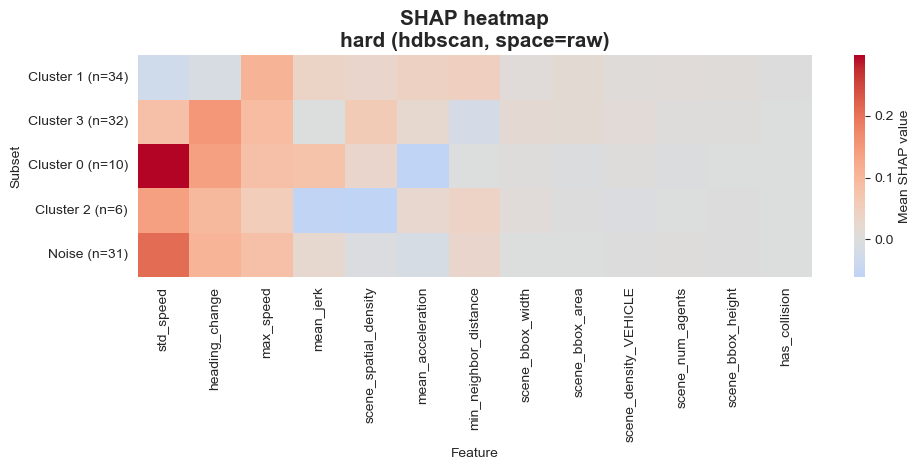

SHAP bar plots saved to: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/shap_performance_regimes/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__space-raw__selection-all/plots/cluster_profile_barplots__group-hard__alg-hdbscan__space-raw.png
SHAP heatmap saved to: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/shap_performance_regimes/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__space-raw__selection-all/plots/cluster_profile_heatm

In [15]:
cluster_profile_barplot_path = PLOTS_DIR / (
    'cluster_profile_barplots__'
    f"group-{slugify_token(inspection_bundle.performance_group)}__"
    f"alg-{slugify_token(inspection_bundle.algorithm)}__"
    f"space-{slugify_token(inspection_bundle.cluster_space)}.png"
)
cluster_profile_heatmap_path = PLOTS_DIR / (
    'cluster_profile_heatmap__'
    f"group-{slugify_token(inspection_bundle.performance_group)}__"
    f"alg-{slugify_token(inspection_bundle.algorithm)}__"
    f"space-{slugify_token(inspection_bundle.cluster_space)}.png"
)

plot_cluster_profile_barplots(
    inspection_bundle.selected_profiles_df,
    shap_cols=selected_shap_cols,
    top_k_features=resolved_inspection_config['inspection_top_k_features'],
    performance_group=inspection_bundle.performance_group,
    algorithm=inspection_bundle.algorithm,
    cluster_space=inspection_bundle.cluster_space,
    plot_path=cluster_profile_barplot_path,
    subset_style_map=subset_style_map,
)
plot_cluster_profile_heatmap(
    inspection_bundle.selected_profiles_df,
    shap_cols=selected_shap_cols,
    performance_group=inspection_bundle.performance_group,
    algorithm=inspection_bundle.algorithm,
    cluster_space=inspection_bundle.cluster_space,
    plot_path=cluster_profile_heatmap_path,
)

print(f'SHAP bar plots saved to: {cluster_profile_barplot_path}')
print(f'SHAP heatmap saved to: {cluster_profile_heatmap_path}')


## Plot Trajectory-Feature Distributions
**Purpose:** Compare every non-`scene_` model-input feature across the selected cluster subsets, noise, and the whole performance-group baseline using prettier inspection-focused figures.<br>
**Inputs:** The selected candidate assignment rows, `inspection_bundle.trajectory_feature_cols`, and `subset_style_map`.<br>
**Outputs:** One saved distribution figure per ordered trajectory feature, with continuous metrics shown as histogram-plus-boxplot layouts and categorical metrics shown as normalized bars.<br>
**How to Verify:** Check that the figure order matches the printed trajectory feature order and that the whole-group baseline remains the final subset in each figure.


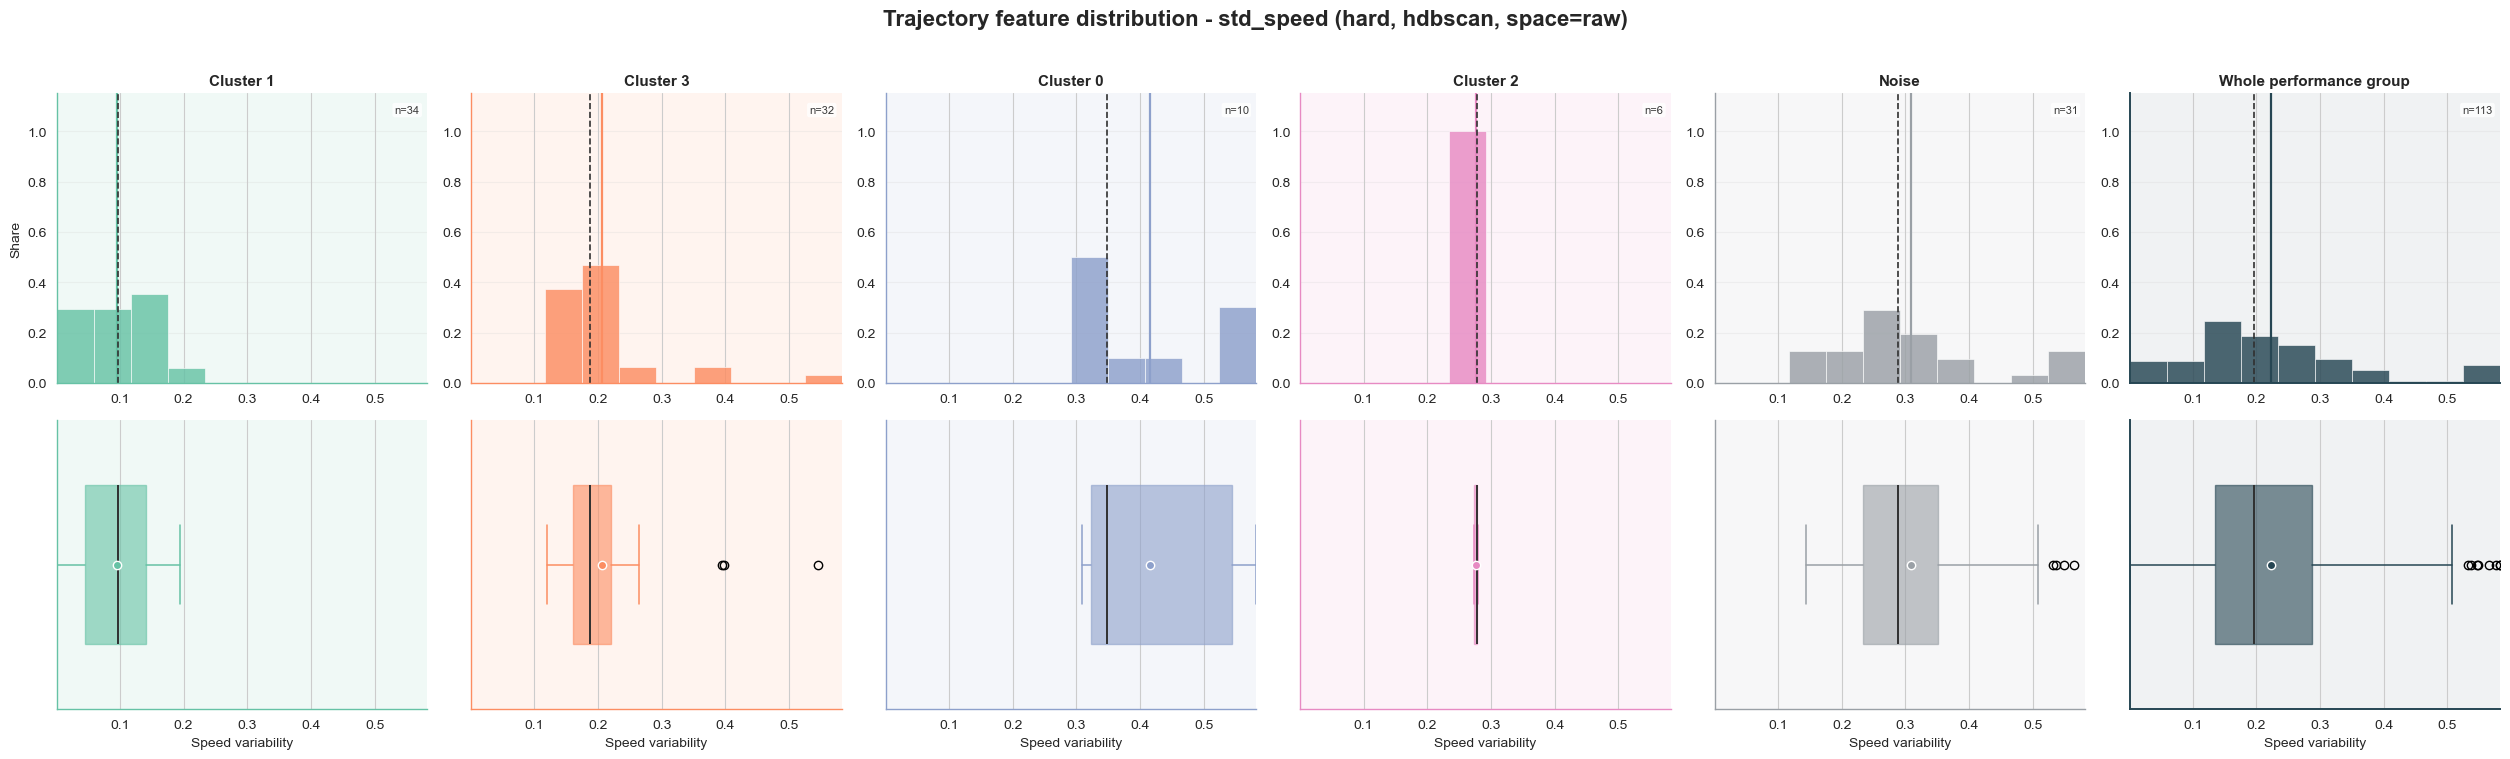

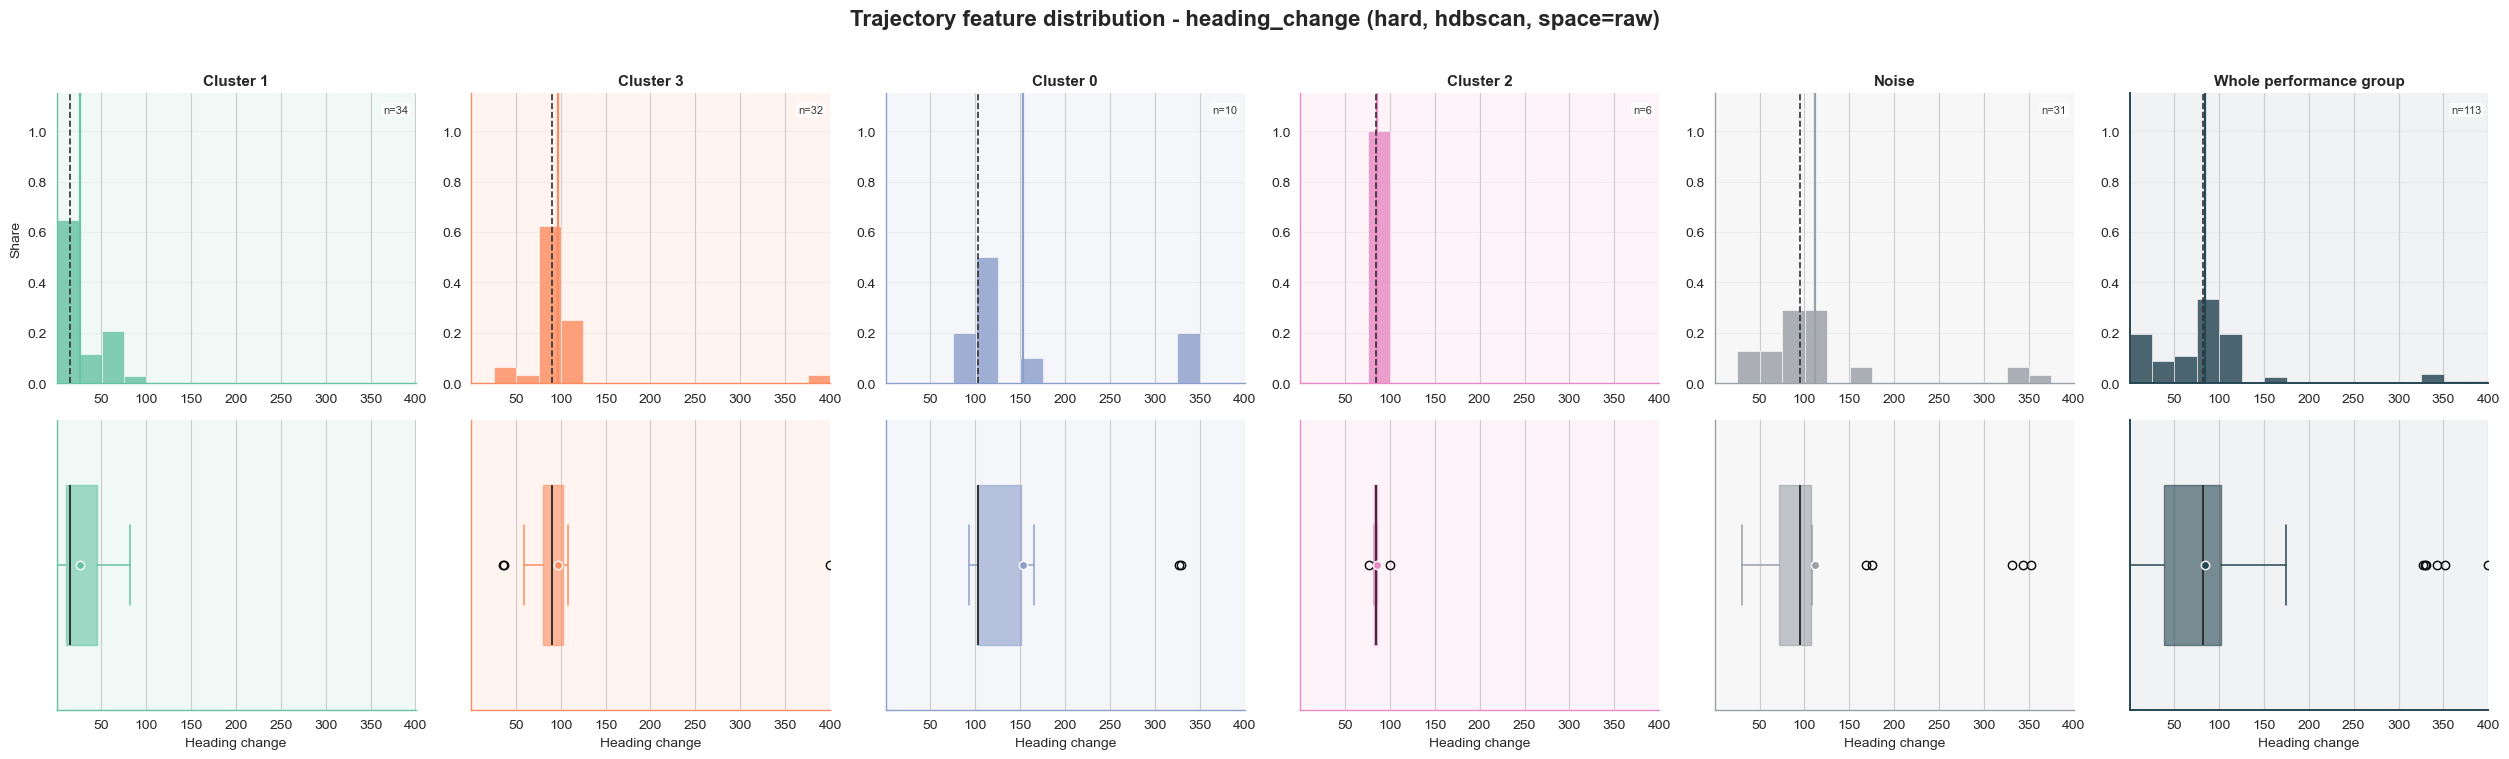

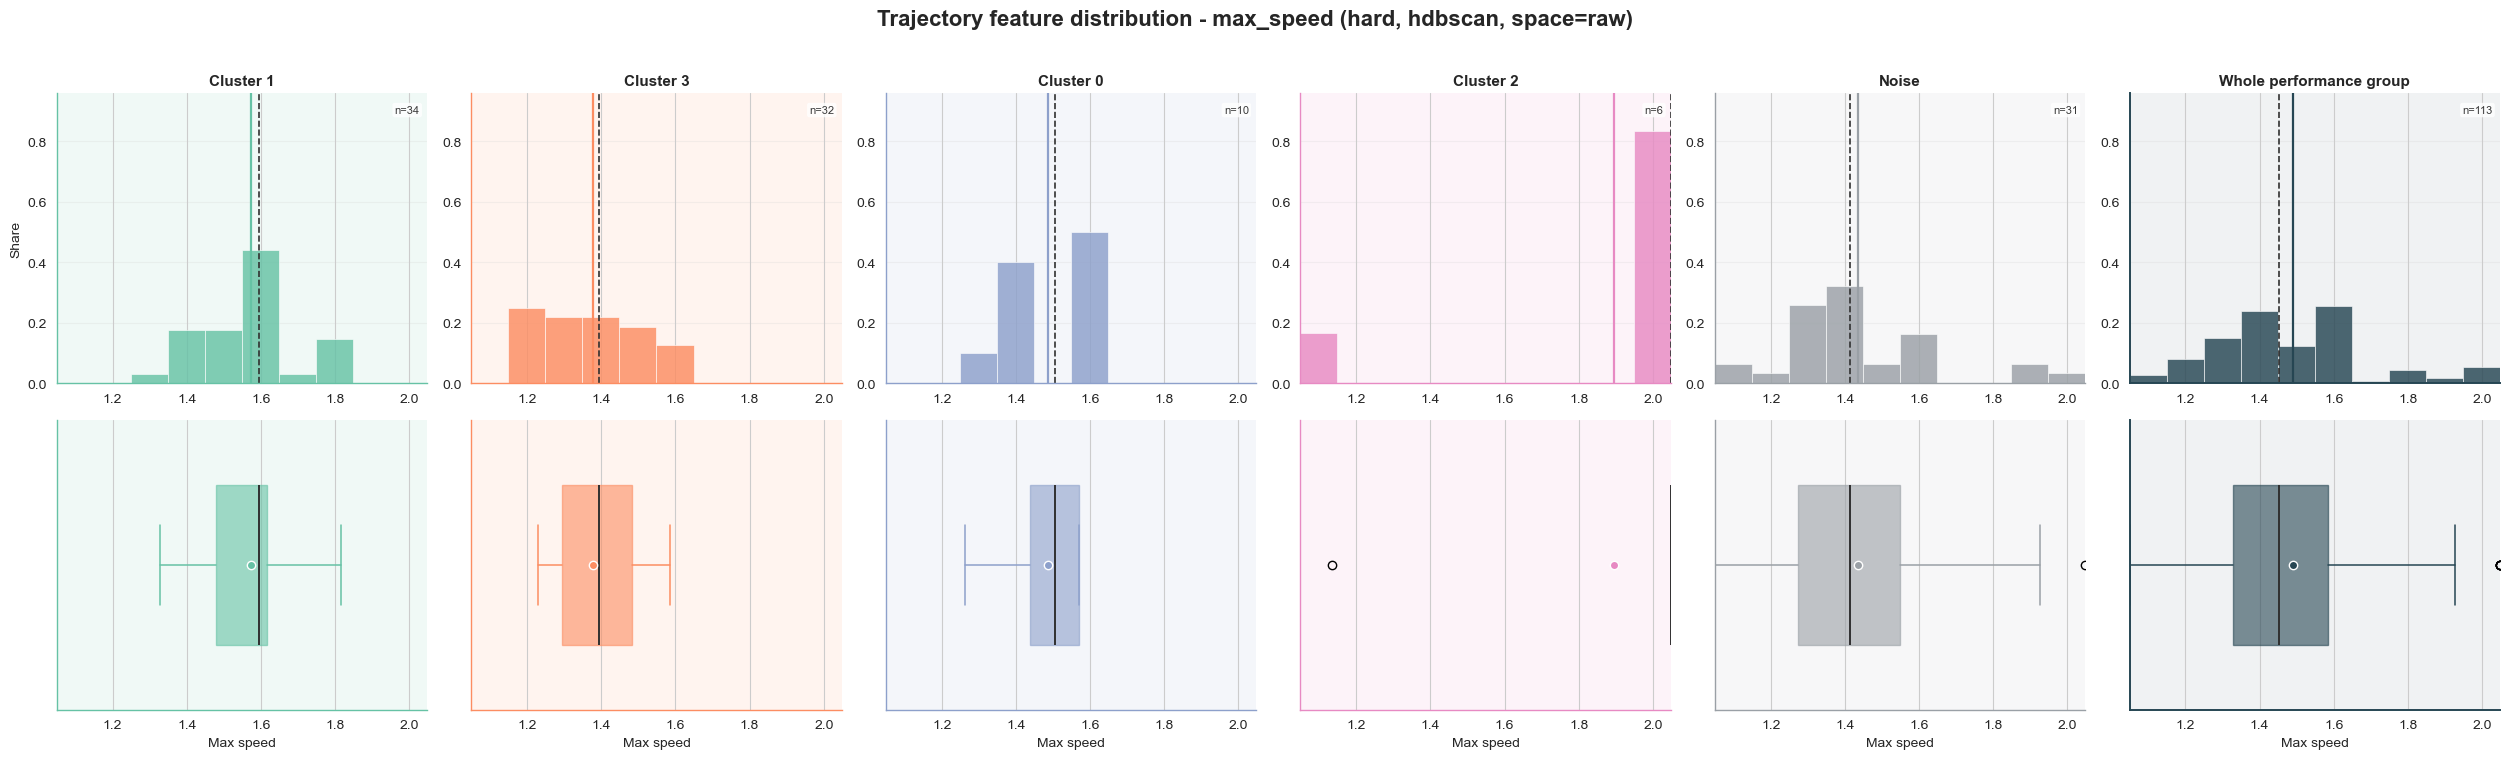

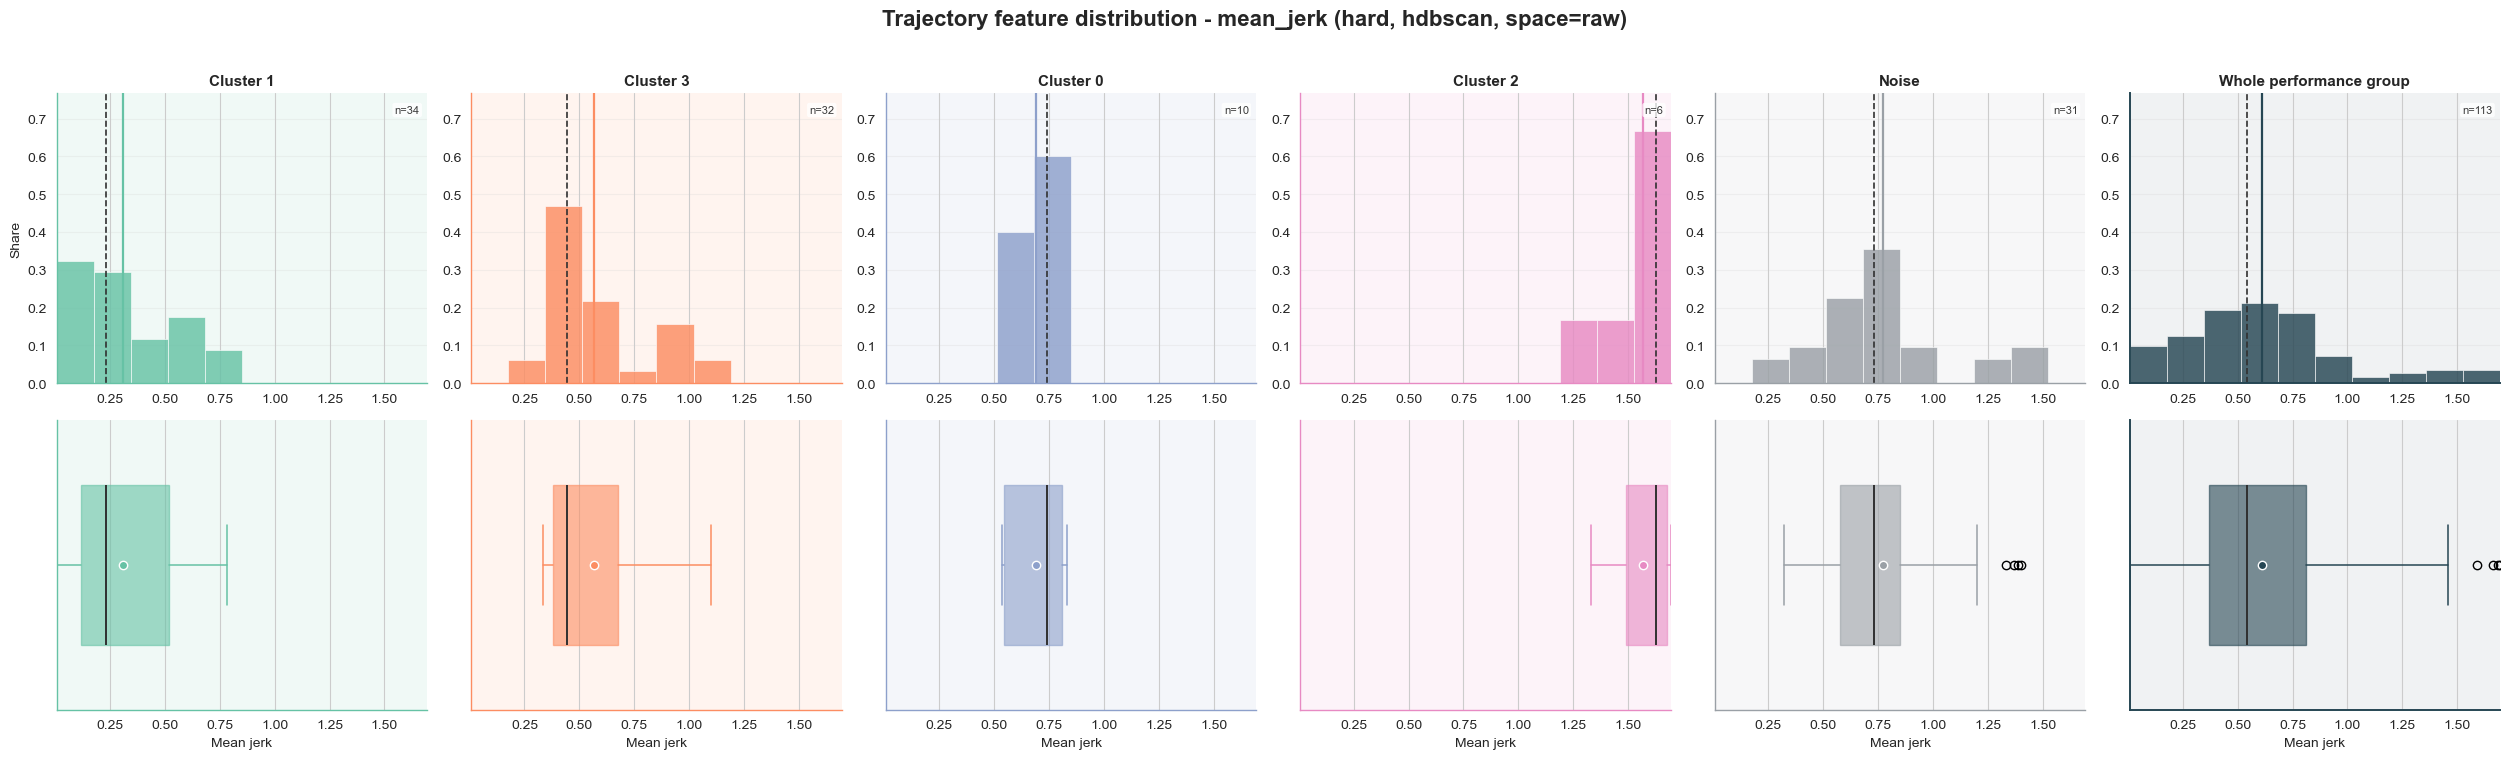

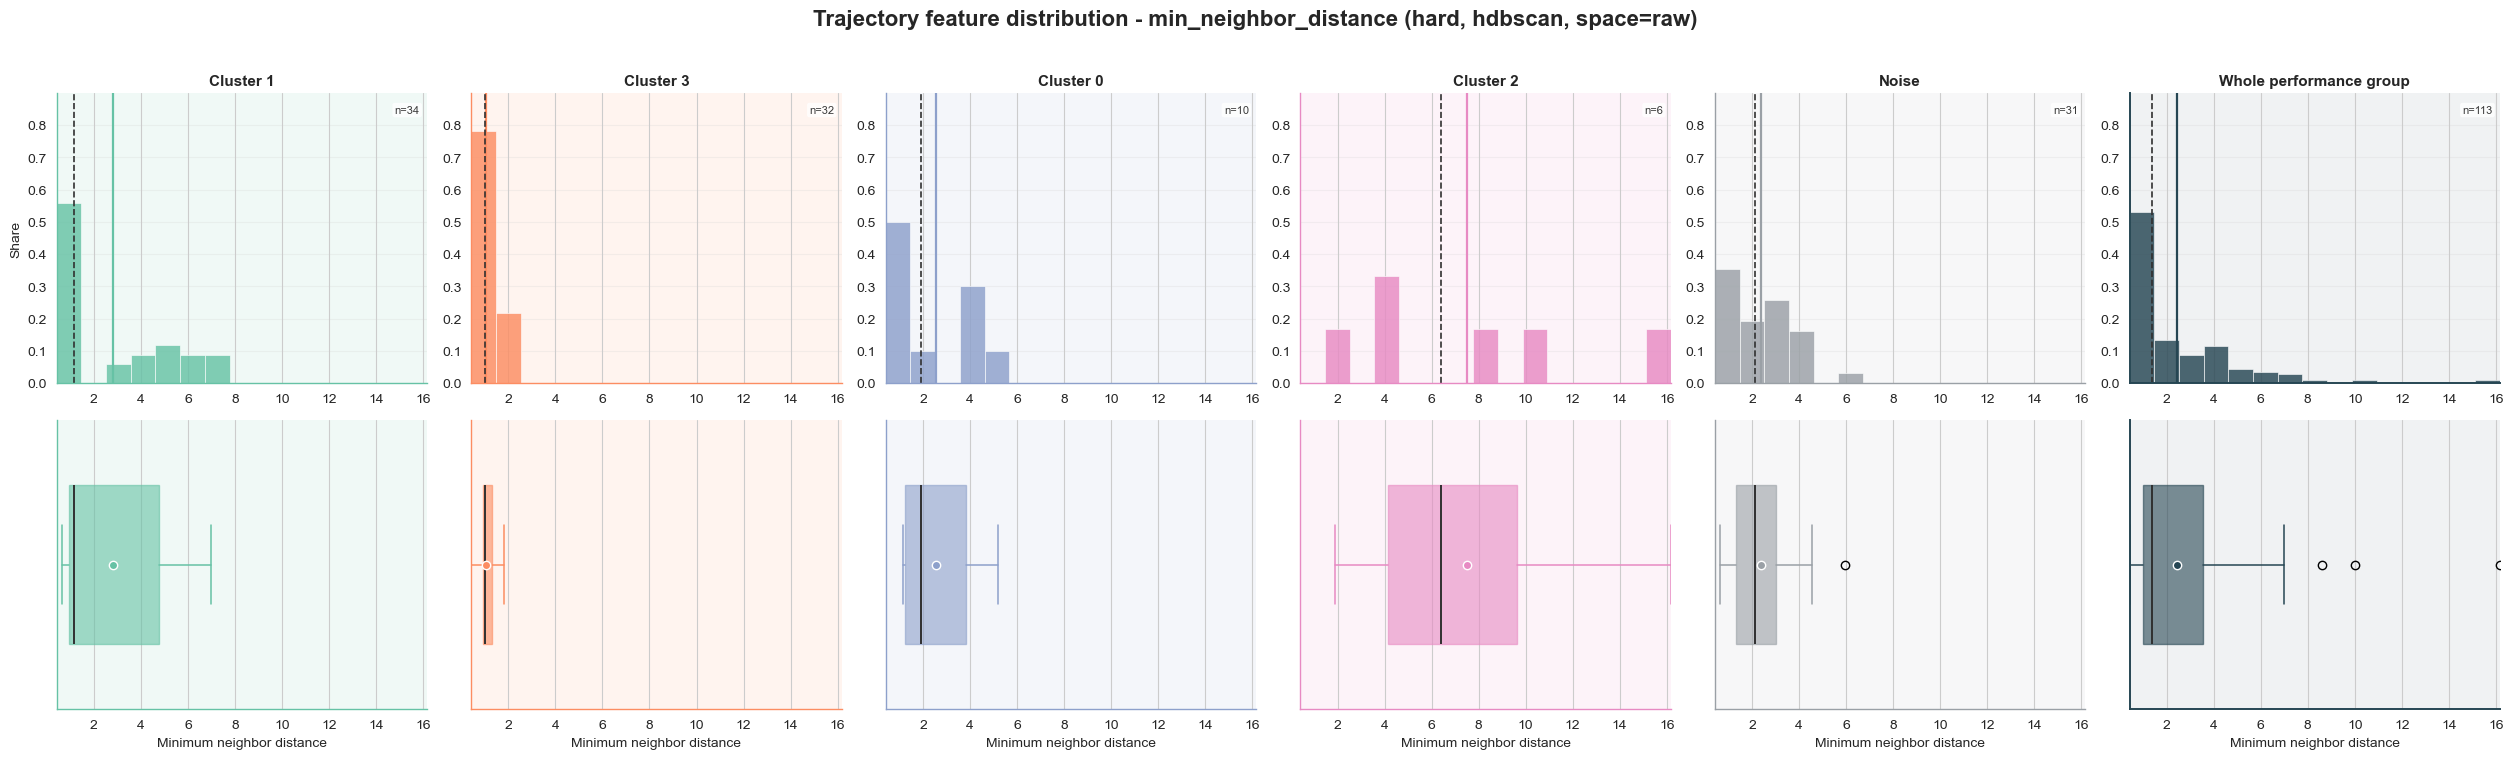

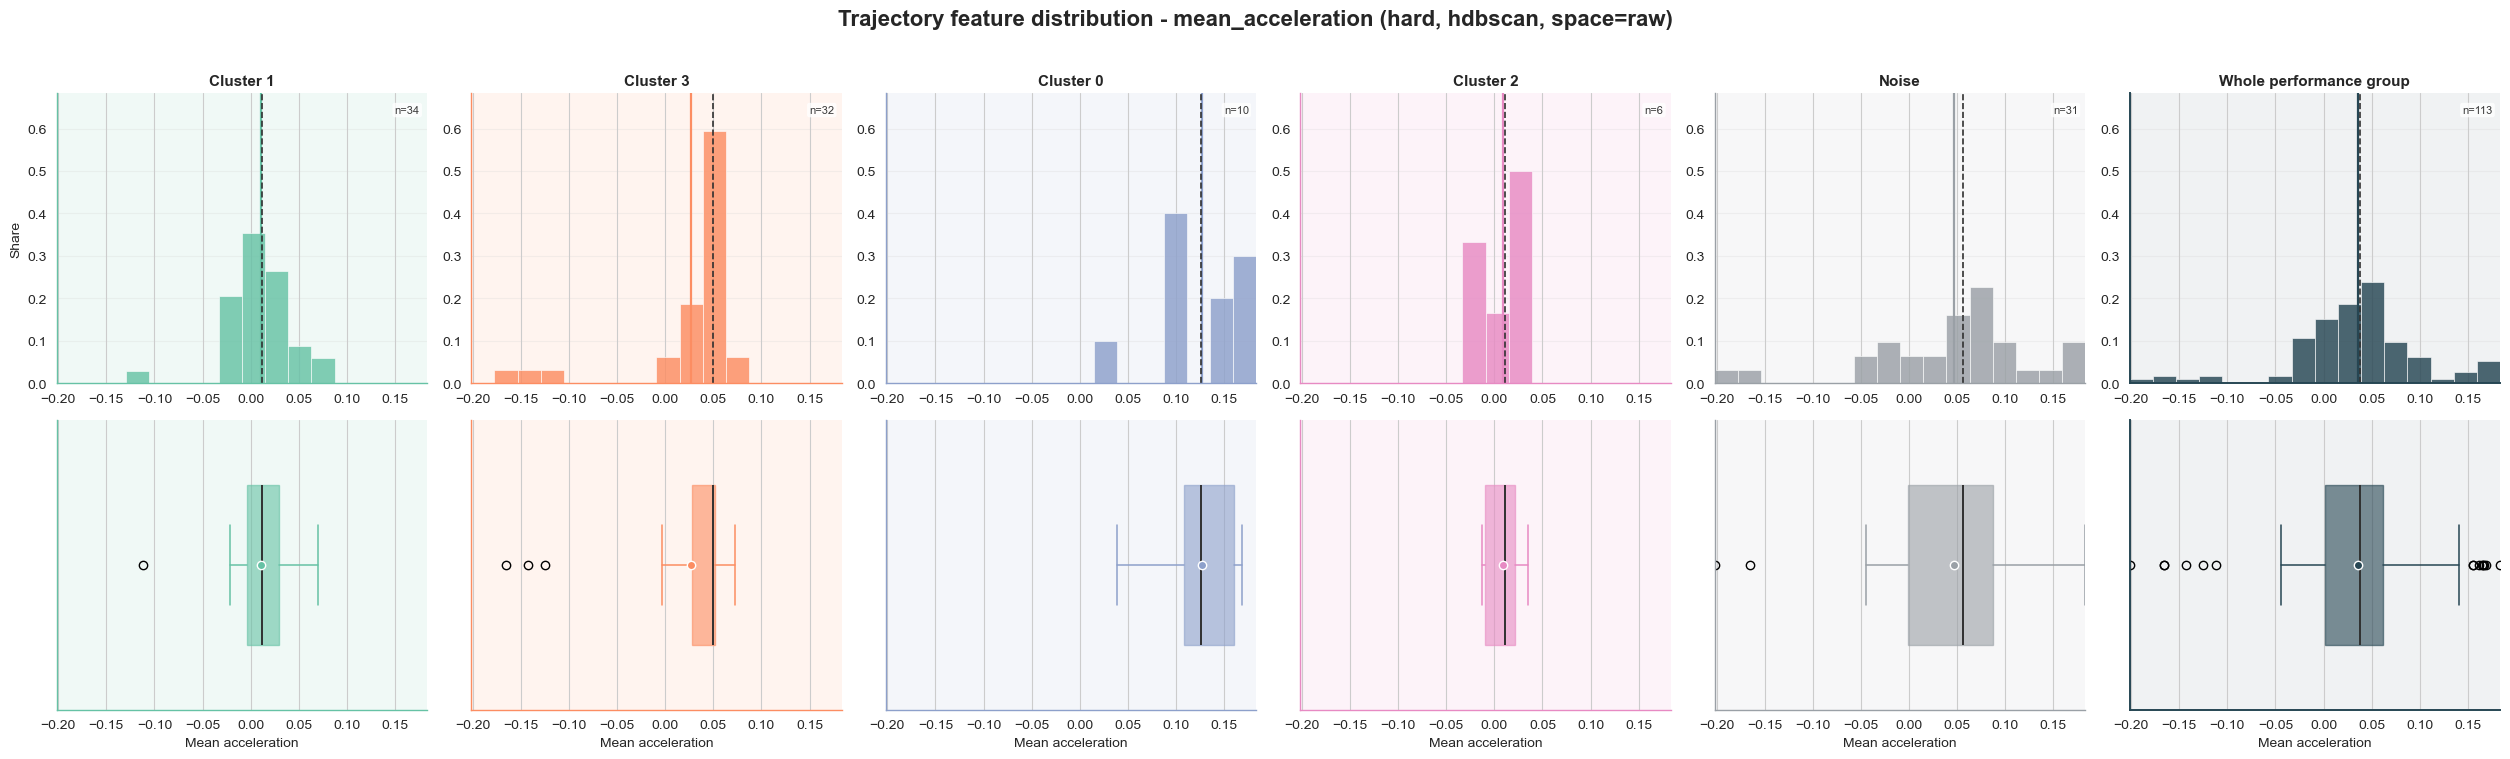

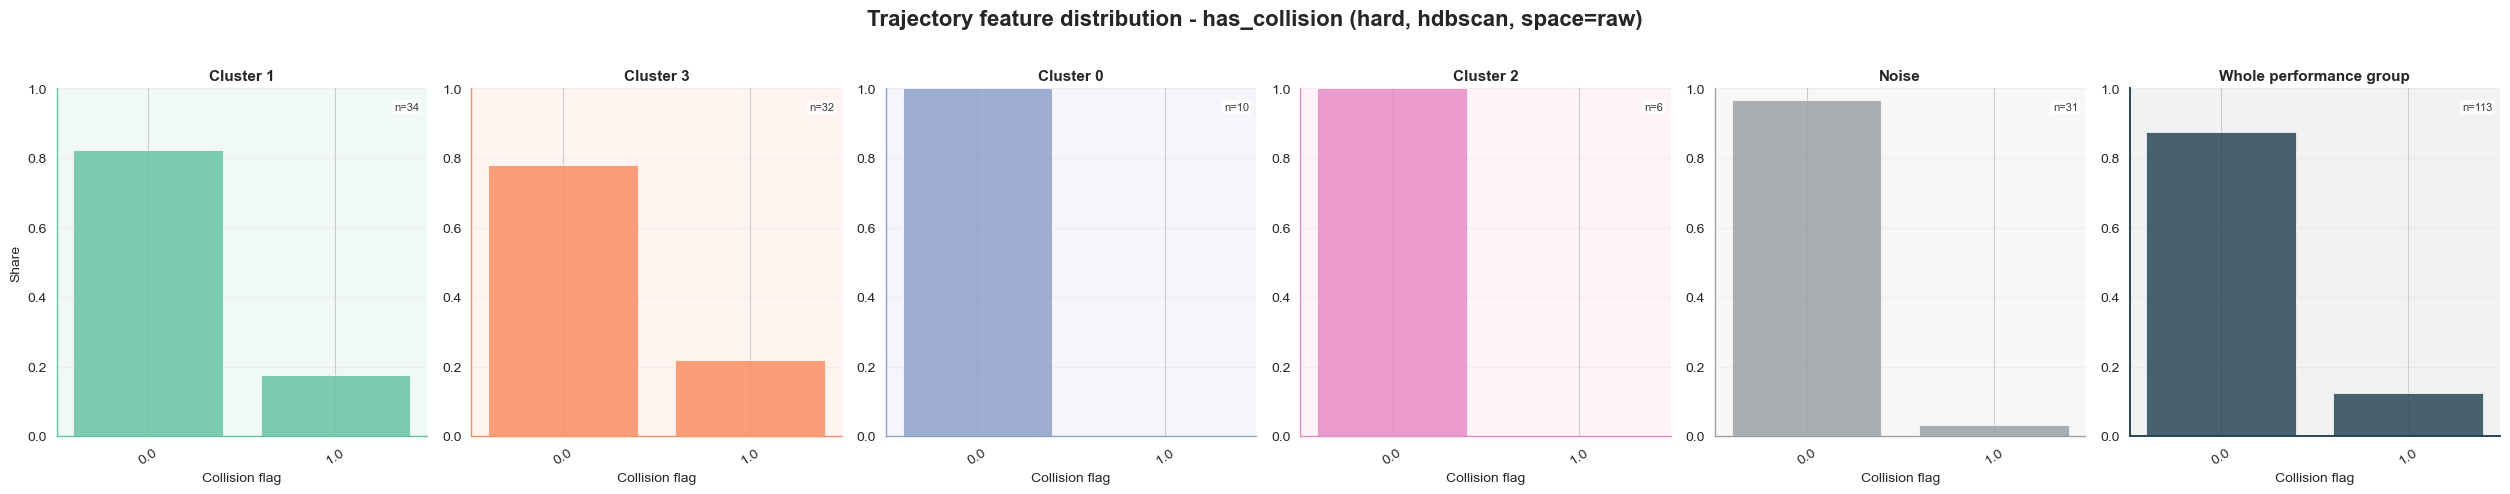

Trajectory feature distribution plots saved: 7
First trajectory feature plot: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/shap_performance_regimes/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__space-raw__selection-all/plots/trajectory_feature_distributions/trajectory_feature_distribution__std_speed.png


In [16]:
trajectory_subset_frames = build_distribution_subset_frames(inspection_bundle, scene_level=False)
trajectory_plot_paths = []

if not inspection_bundle.trajectory_feature_cols:
    print('No non-scene trajectory features were found in the exported assignment table.')
else:
    for feature_col in inspection_bundle.trajectory_feature_cols:
        plot_path = TRAJECTORY_DISTRIBUTION_DIR / f'trajectory_feature_distribution__{slugify_token(feature_col)}.png'
        plot_metric_distribution_panels(
            trajectory_subset_frames,
            metric_col=feature_col,
            plot_title=(
                f"Trajectory feature distribution - {feature_col} "
                f"({inspection_bundle.performance_group}, {inspection_bundle.algorithm}, space={inspection_bundle.cluster_space})"
            ),
            plot_path=plot_path,
            subset_style_map=subset_style_map,
        )
        trajectory_plot_paths.append(plot_path)

print(f'Trajectory feature distribution plots saved: {len(trajectory_plot_paths)}')
if trajectory_plot_paths:
    print(f'First trajectory feature plot: {trajectory_plot_paths[0]}')


## Plot Scene-Characteristic Distributions
**Purpose:** Compare exported `scene_*` metrics across the selected subsets after deduplicating rows at scene-step granularity, using the same cleaner inspection style.<br>
**Inputs:** The selected candidate assignment rows, `inspection_bundle.scene_metric_cols`, and `subset_style_map`.<br>
**Outputs:** One saved distribution figure per ordered scene metric, using unique scene-step rows instead of trajectory-weighted counts.<br>
**How to Verify:** Confirm that the figure order matches the printed scene metric order and that scene-level sample sizes are lower than or equal to the trajectory-level counts where expected.


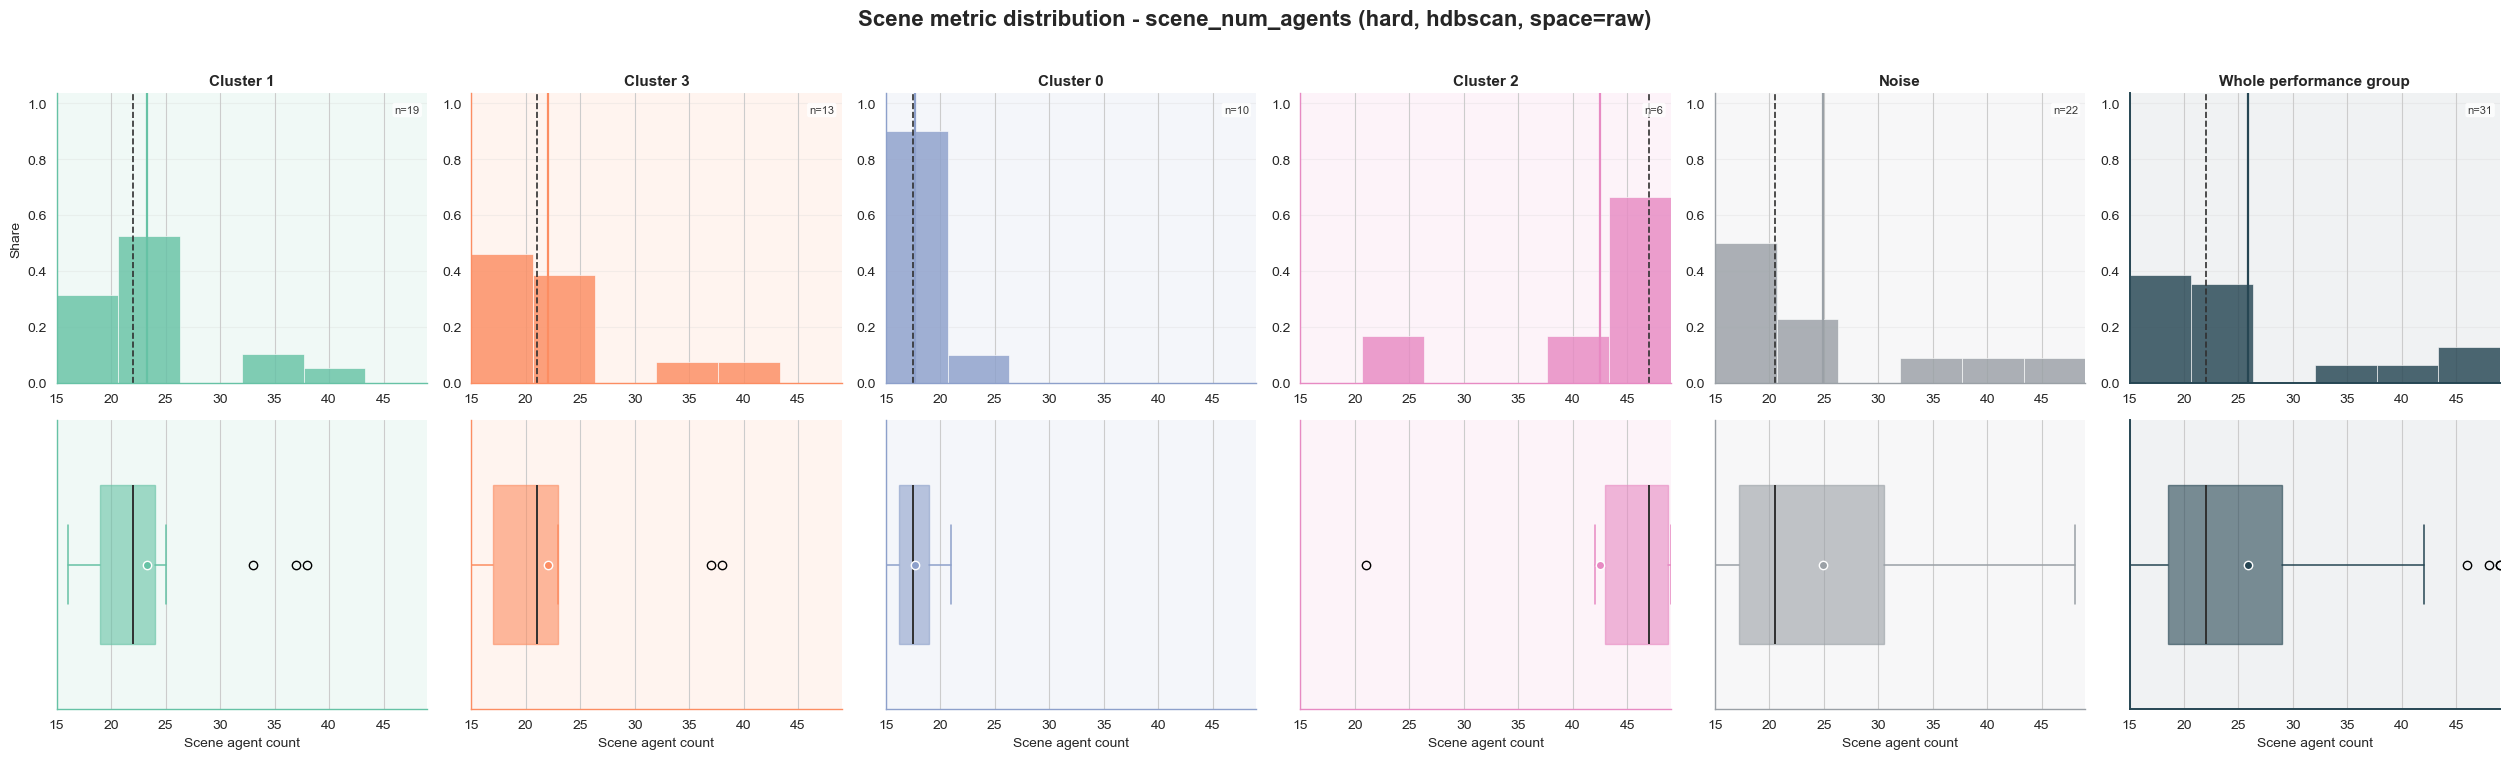

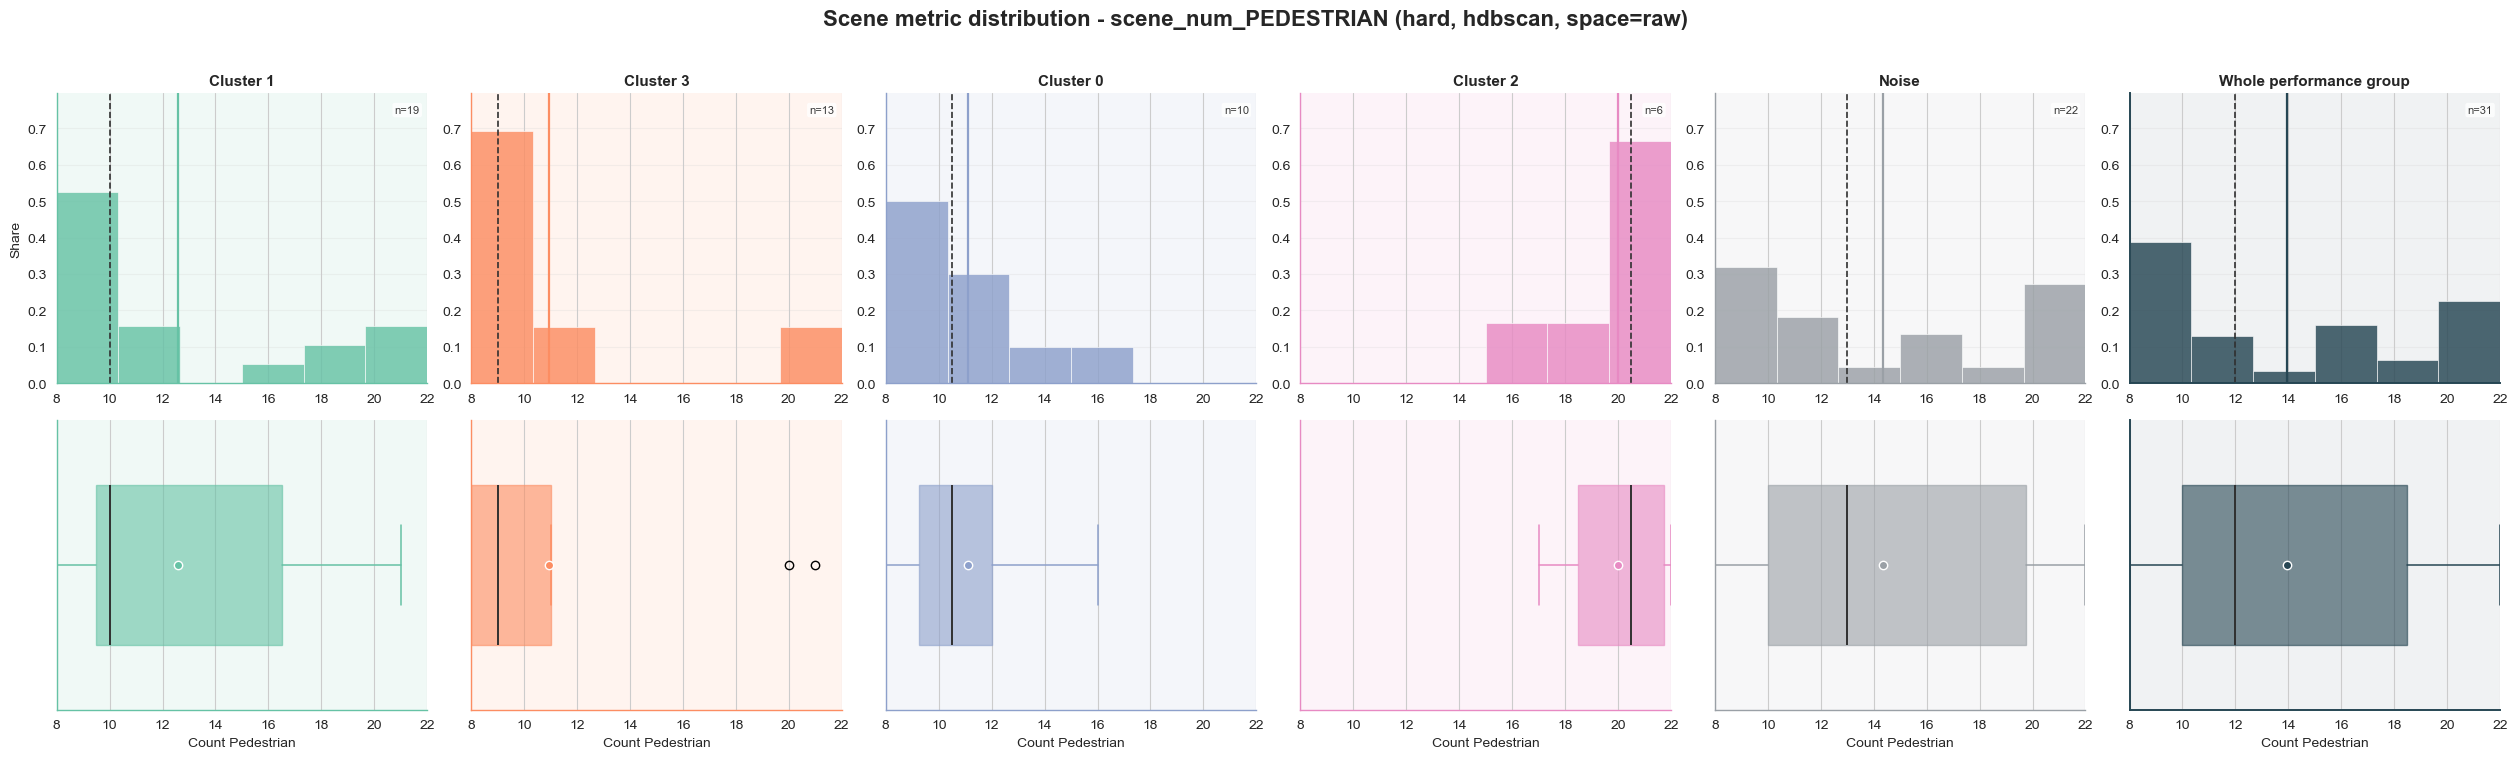

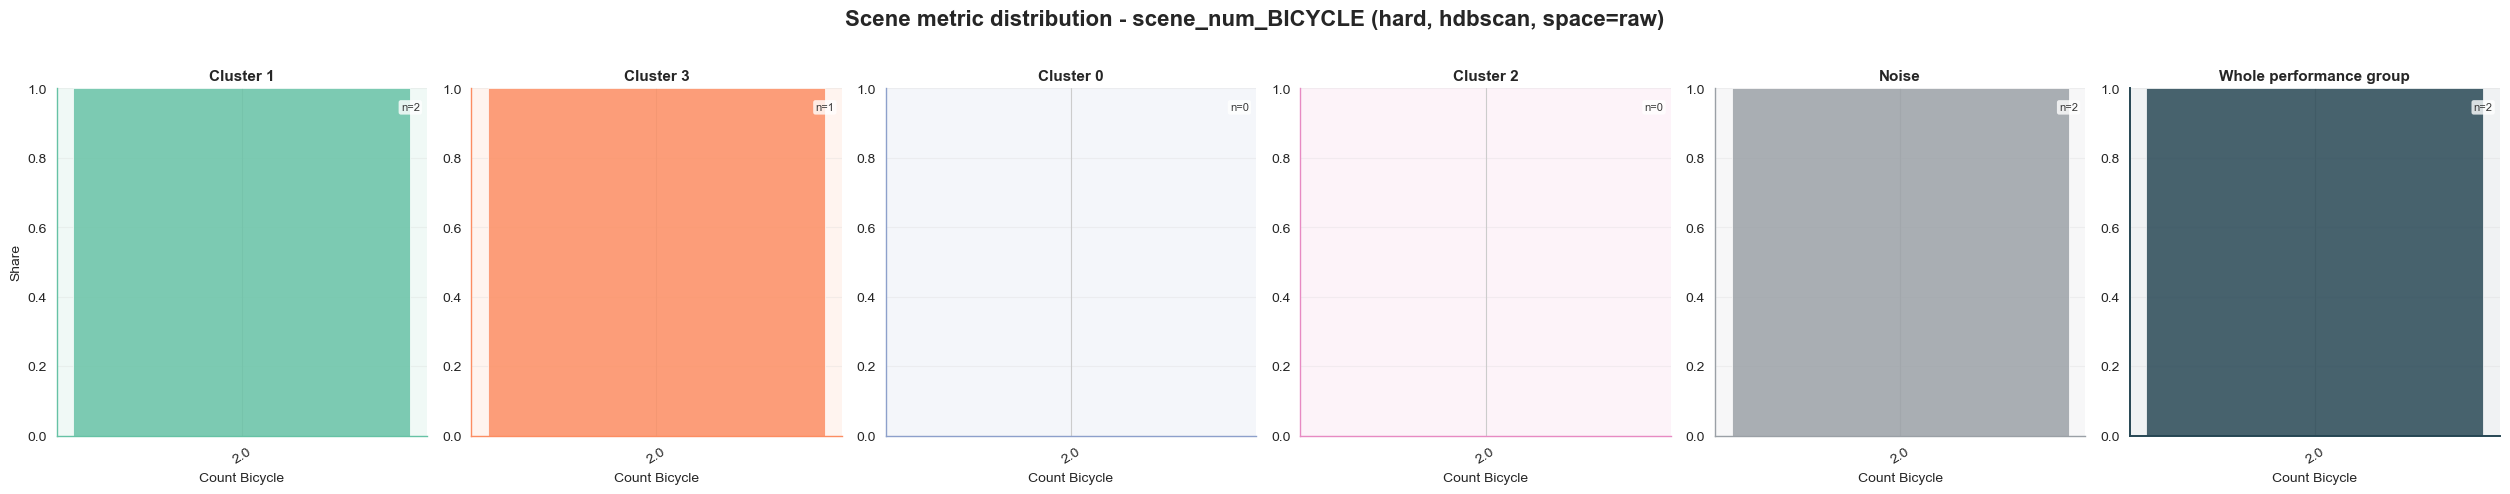

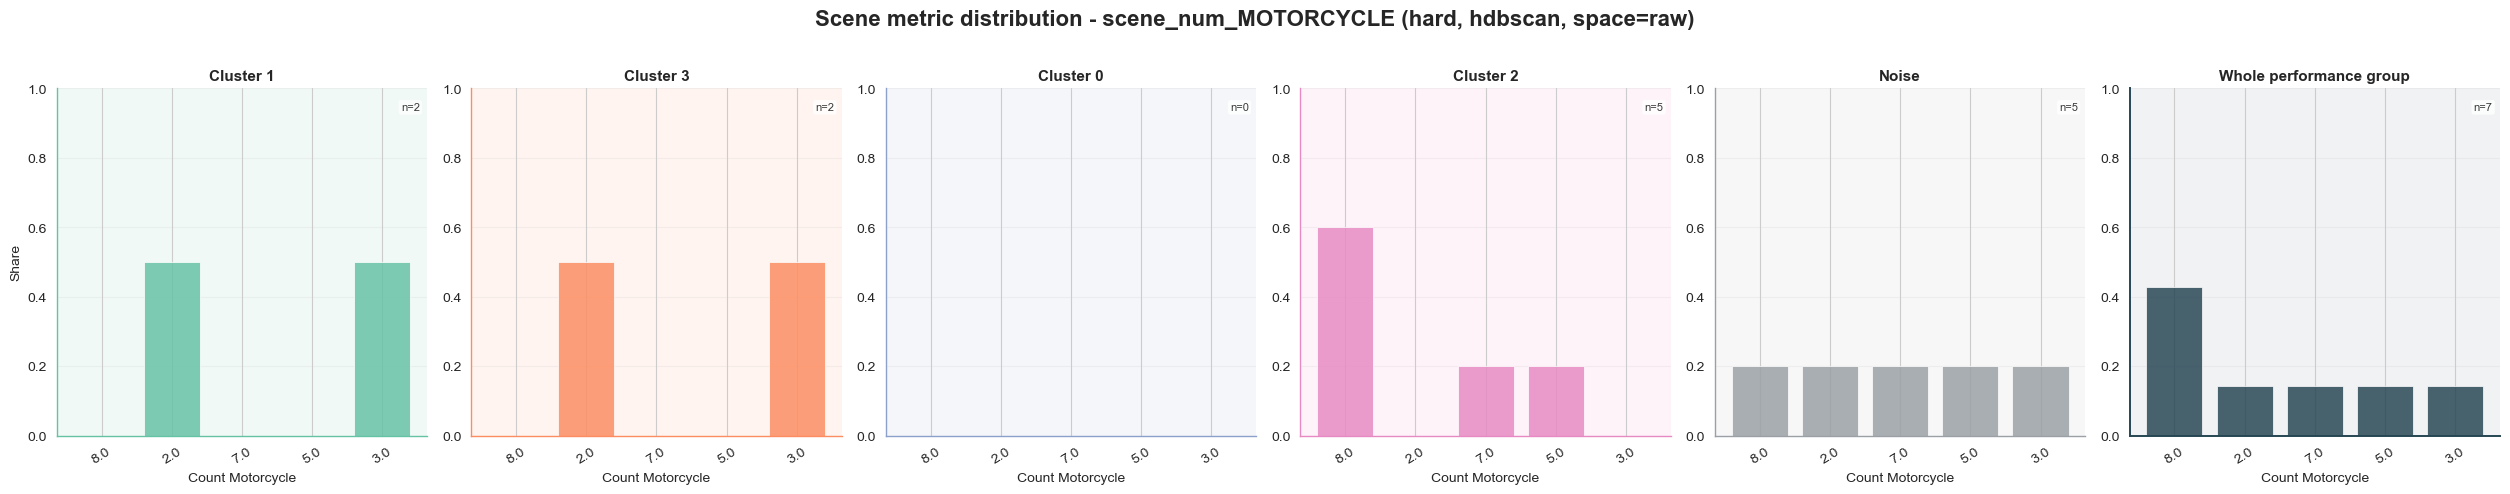

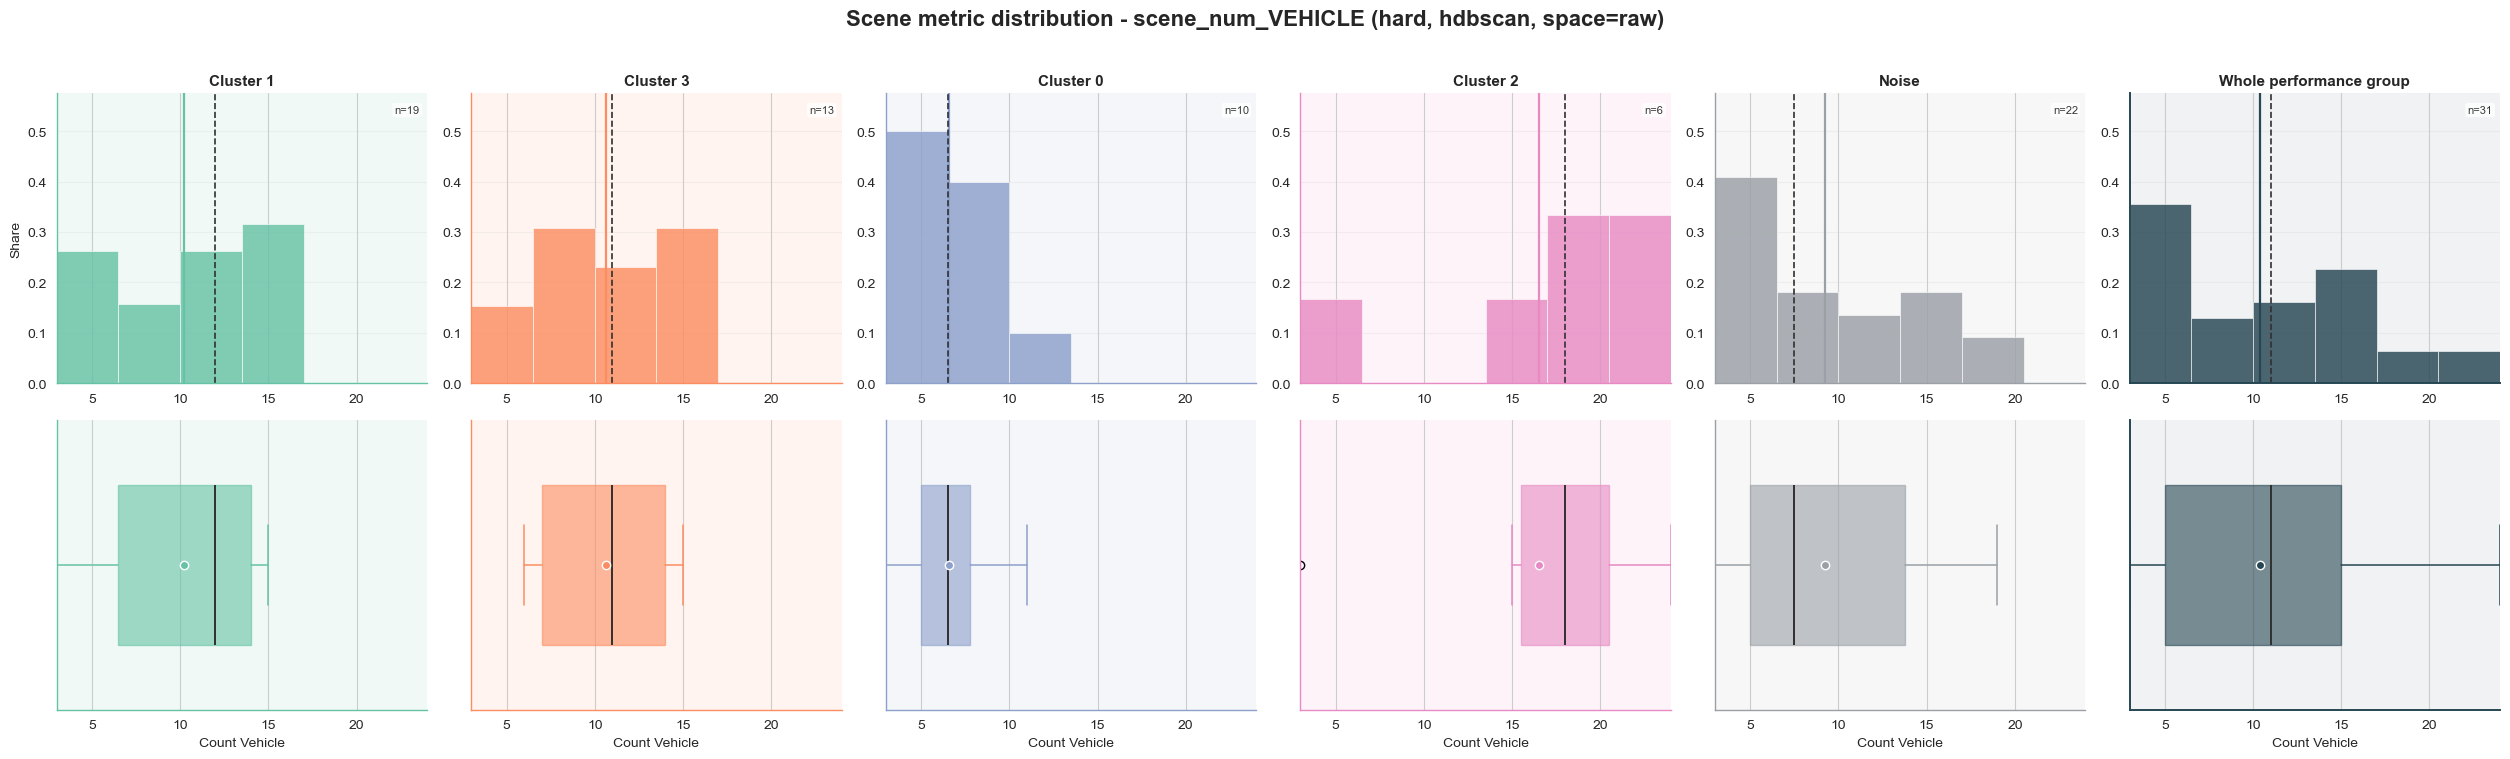

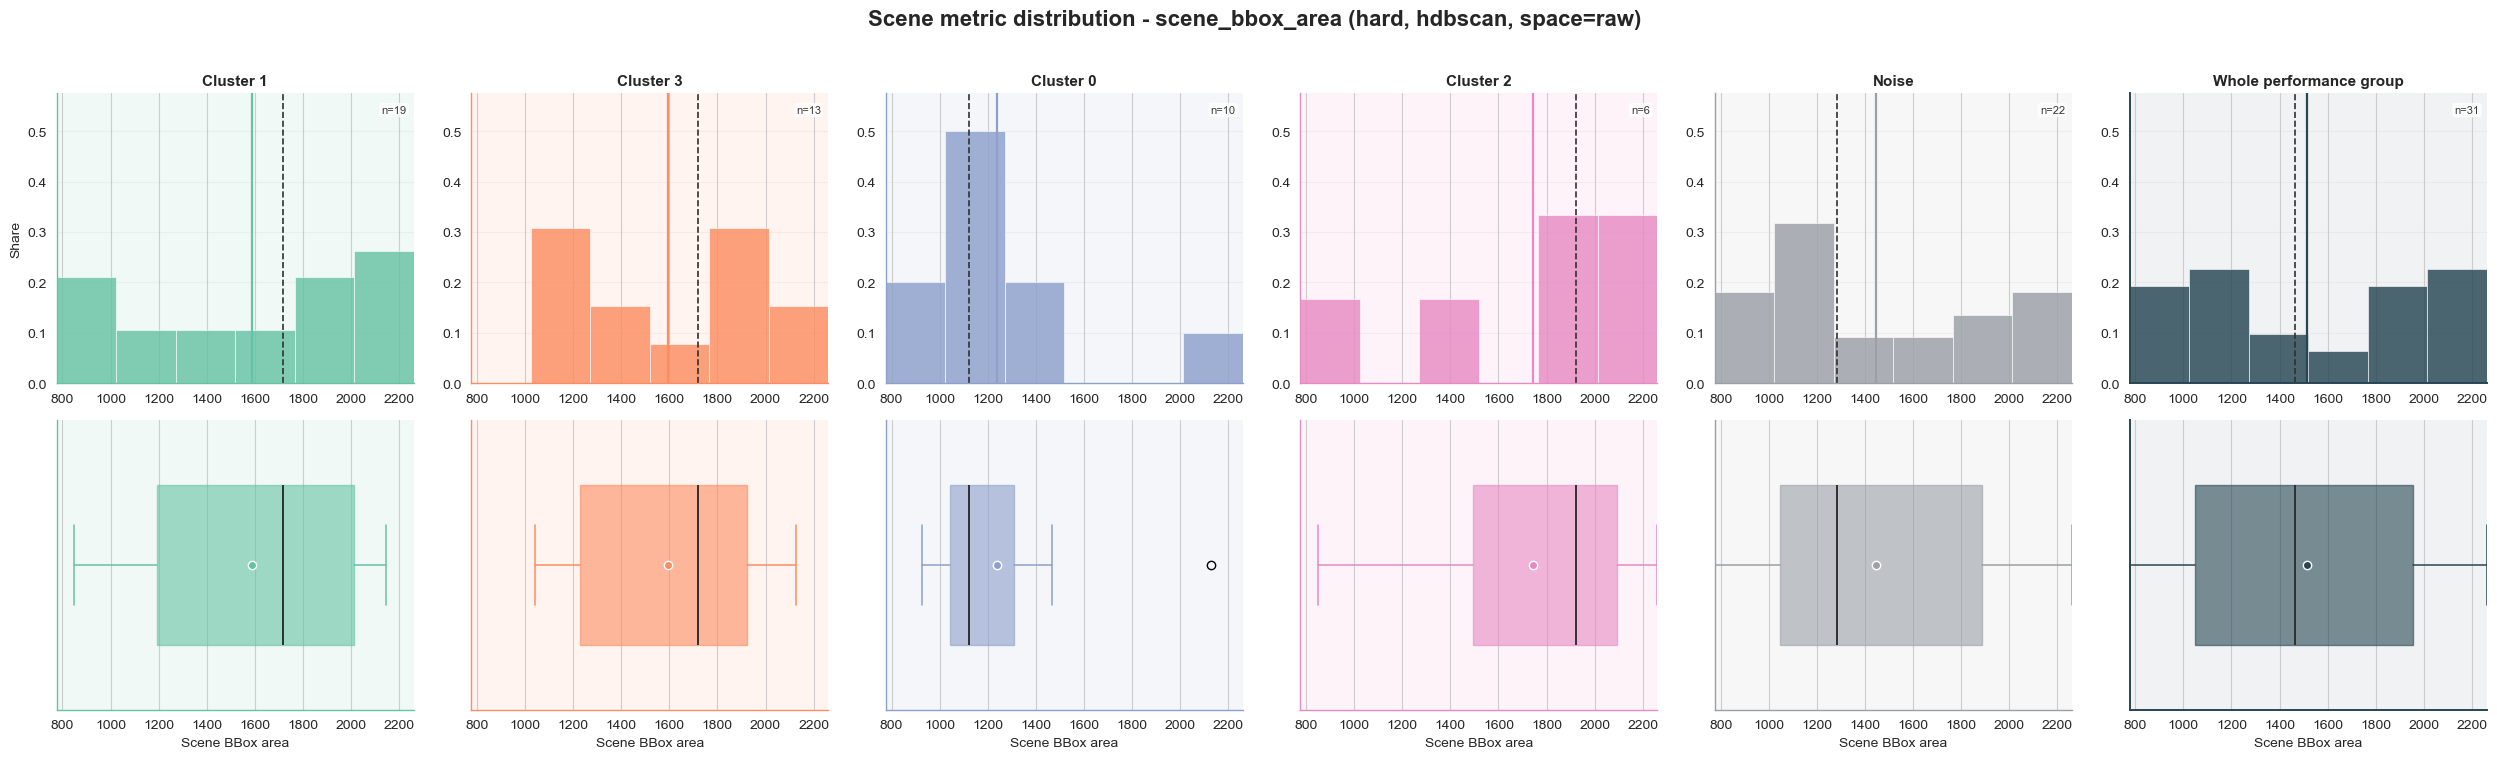

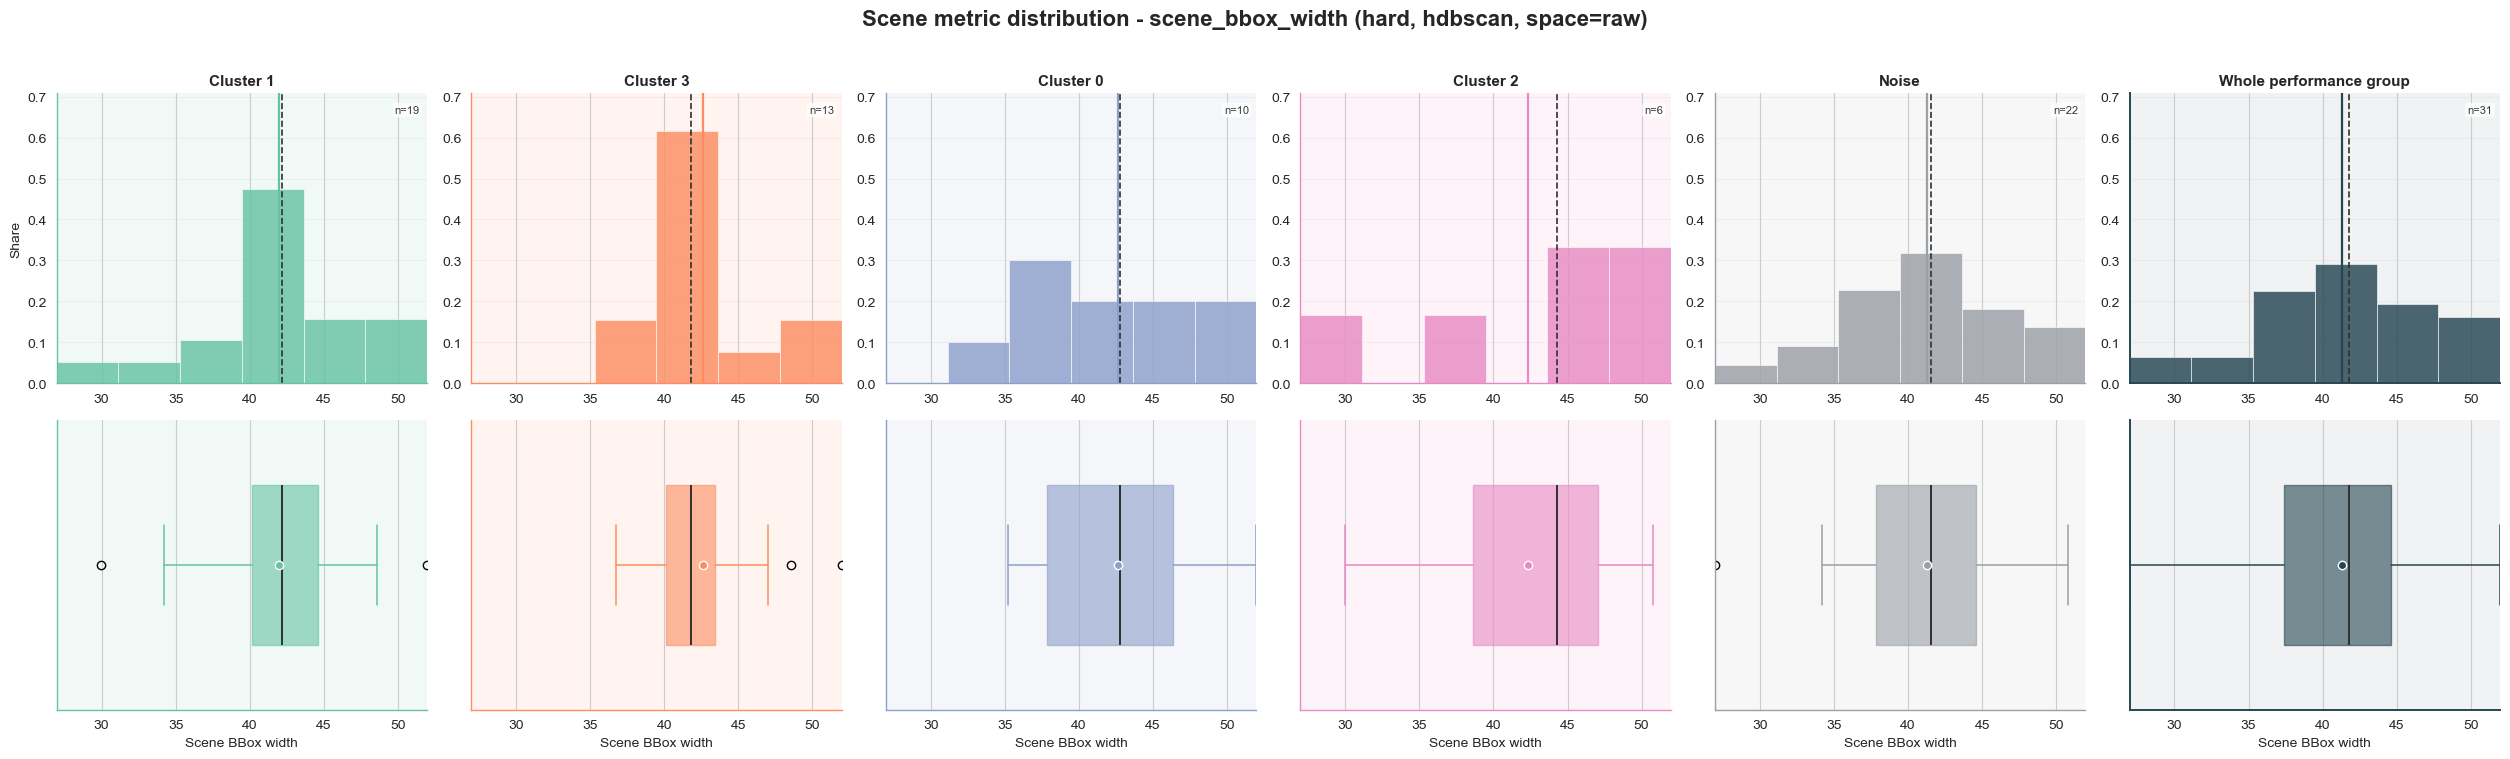

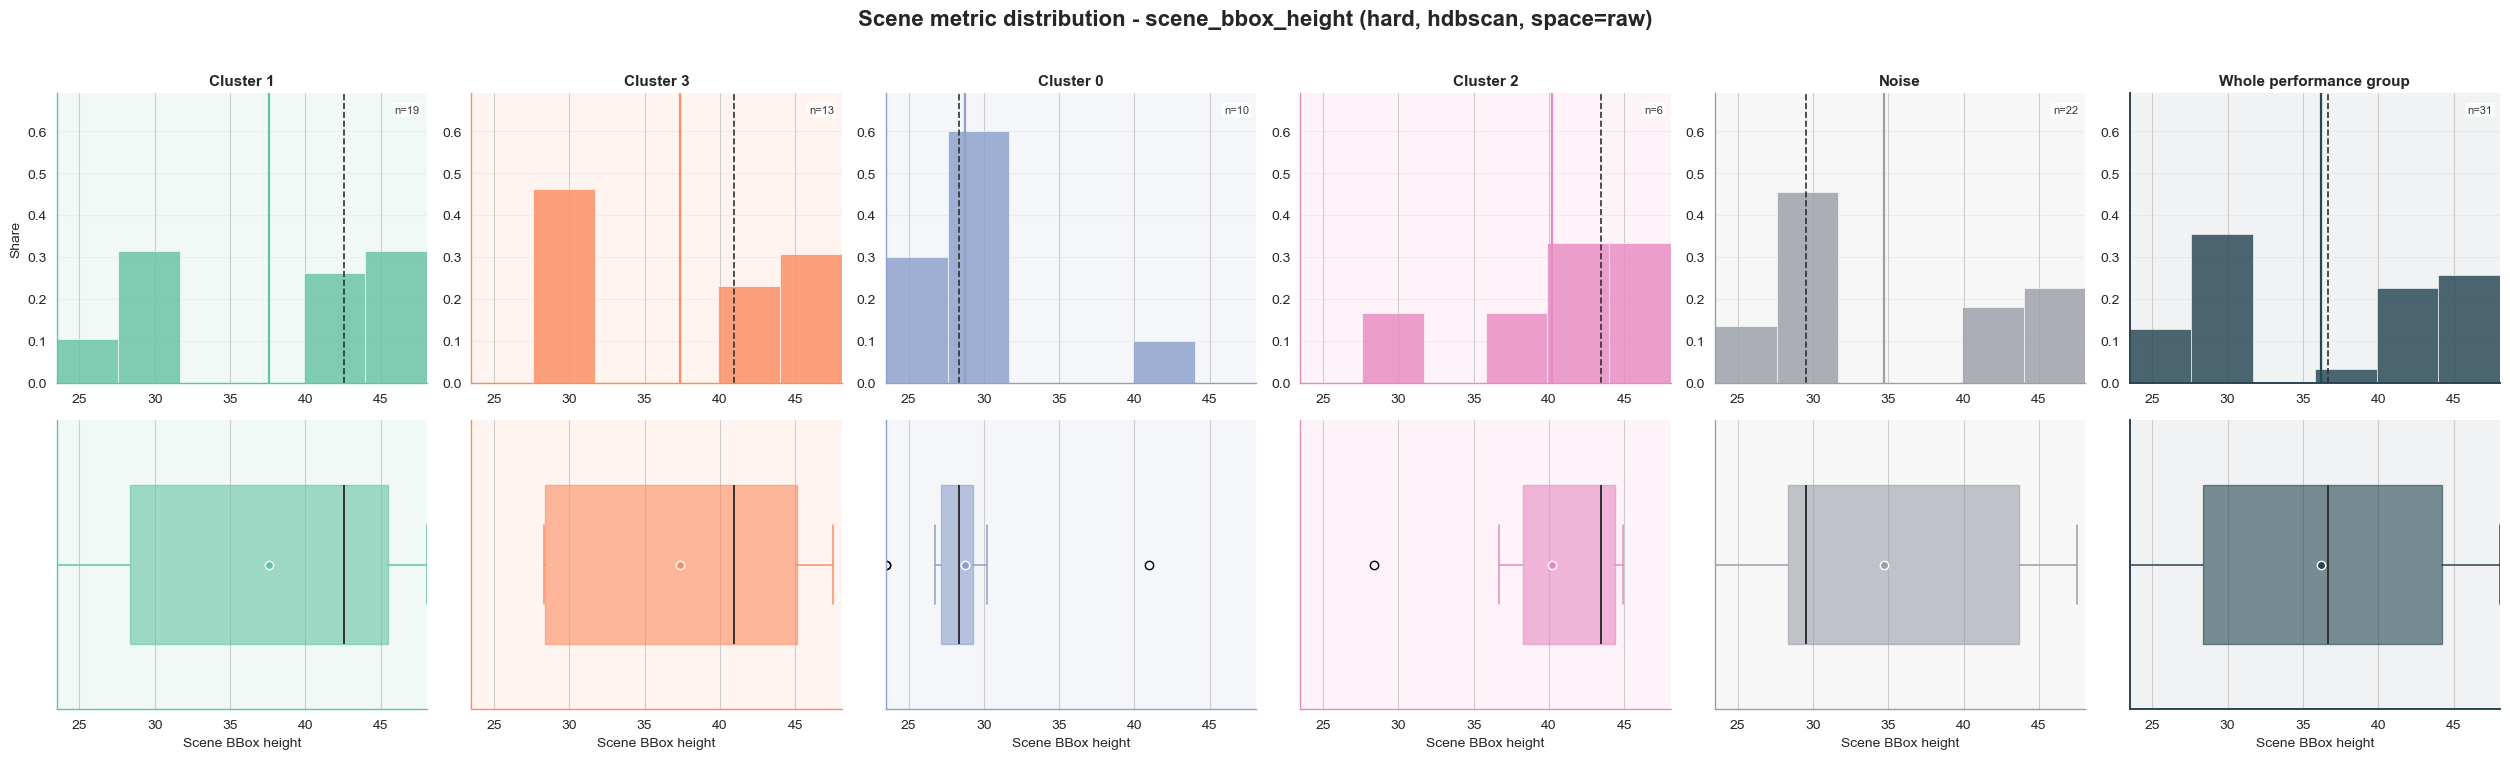

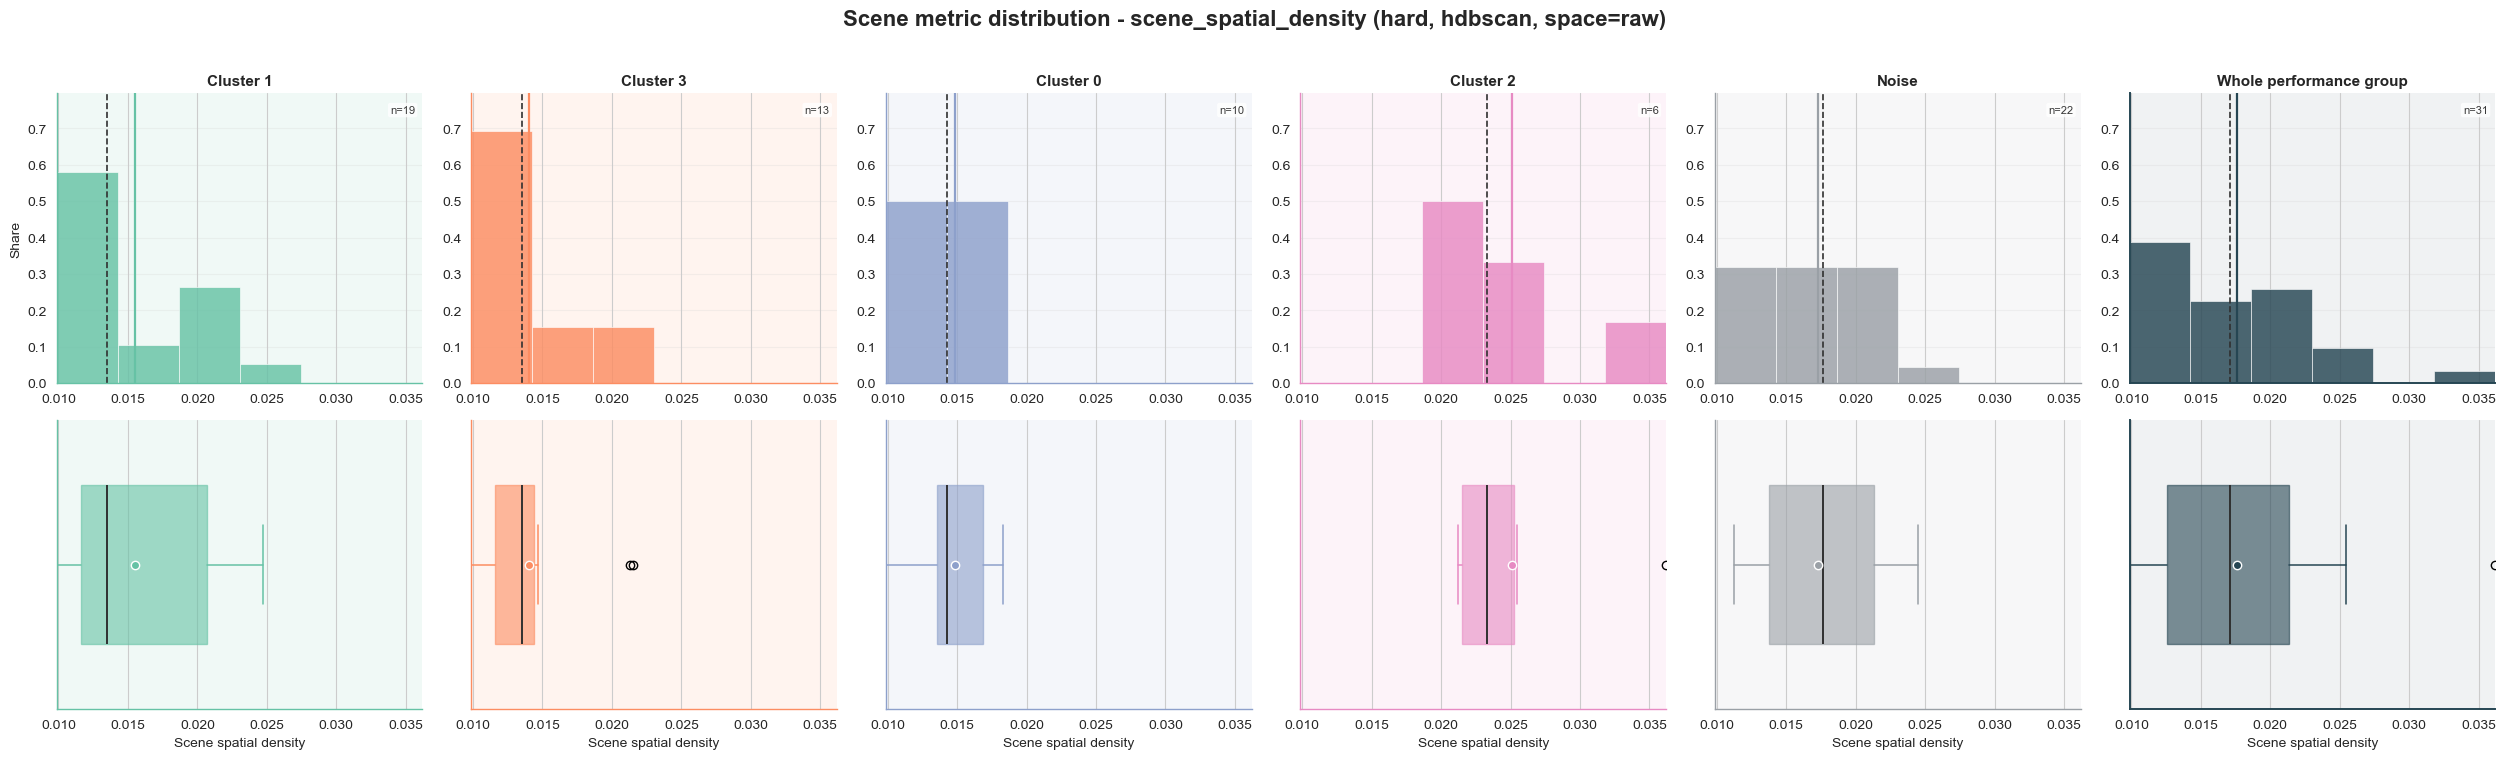

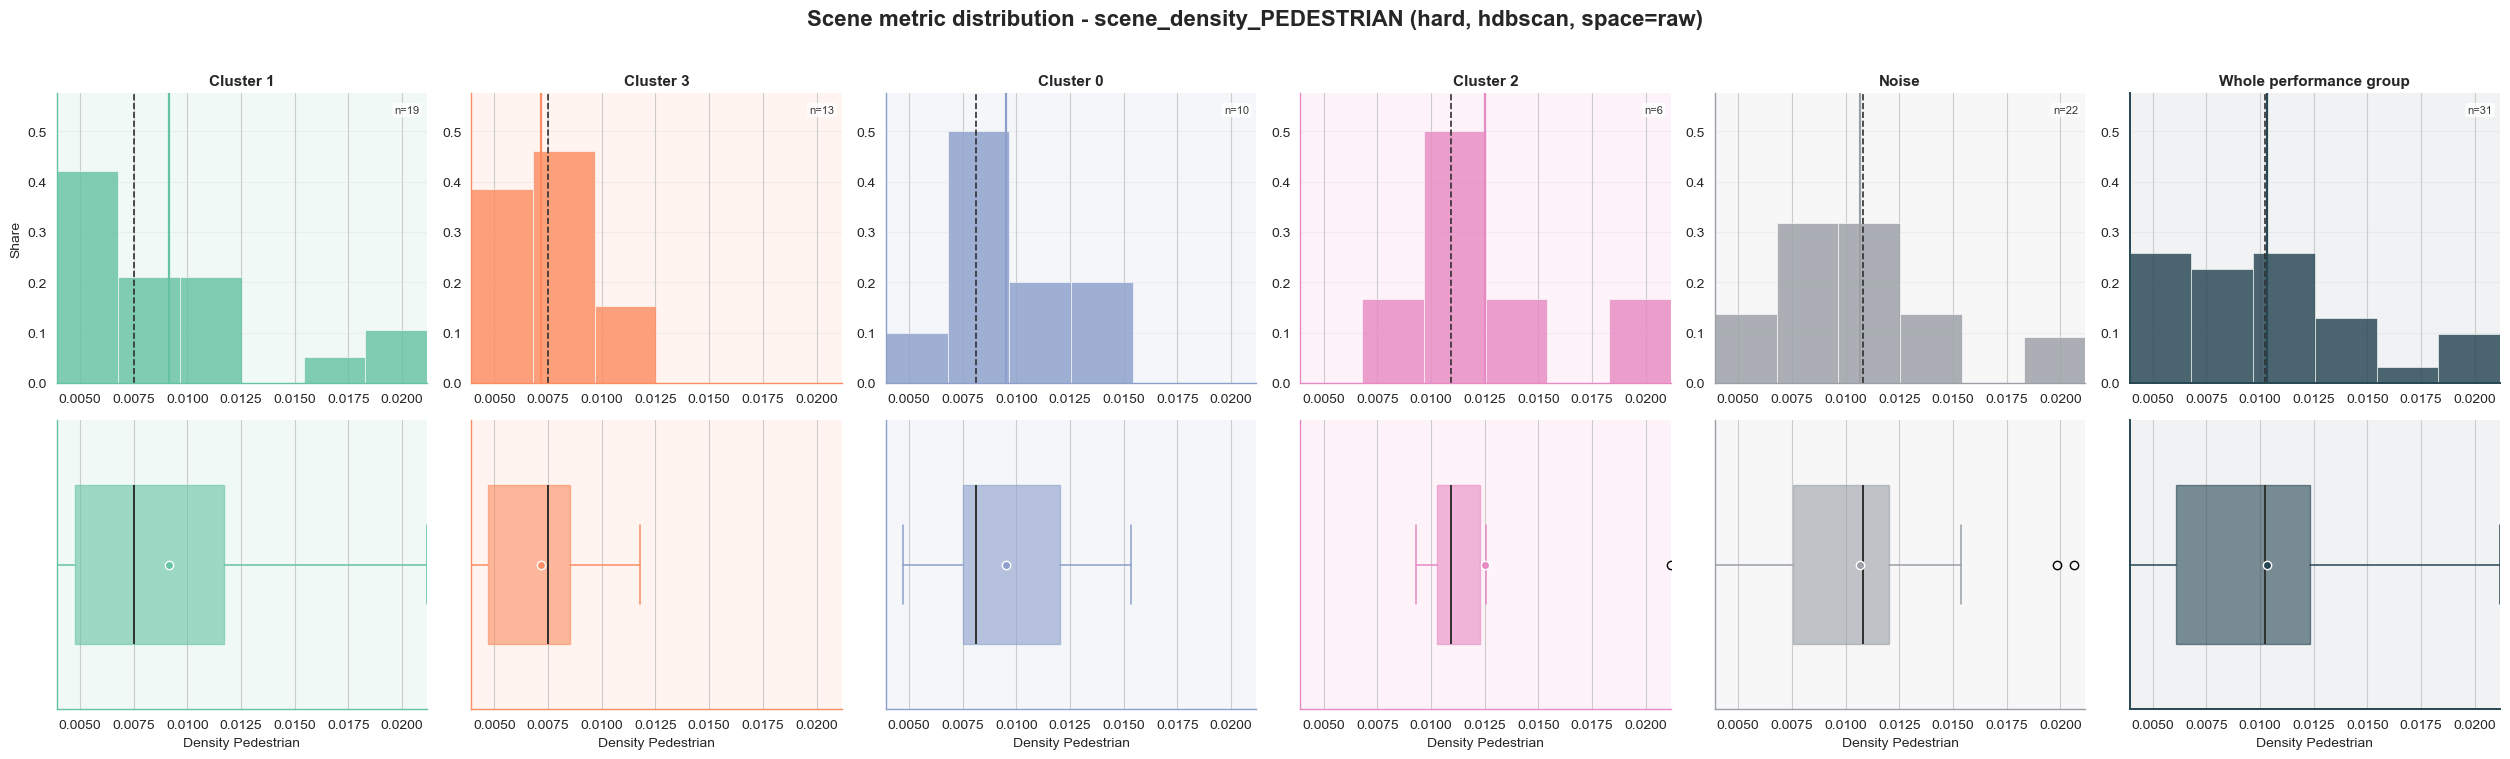

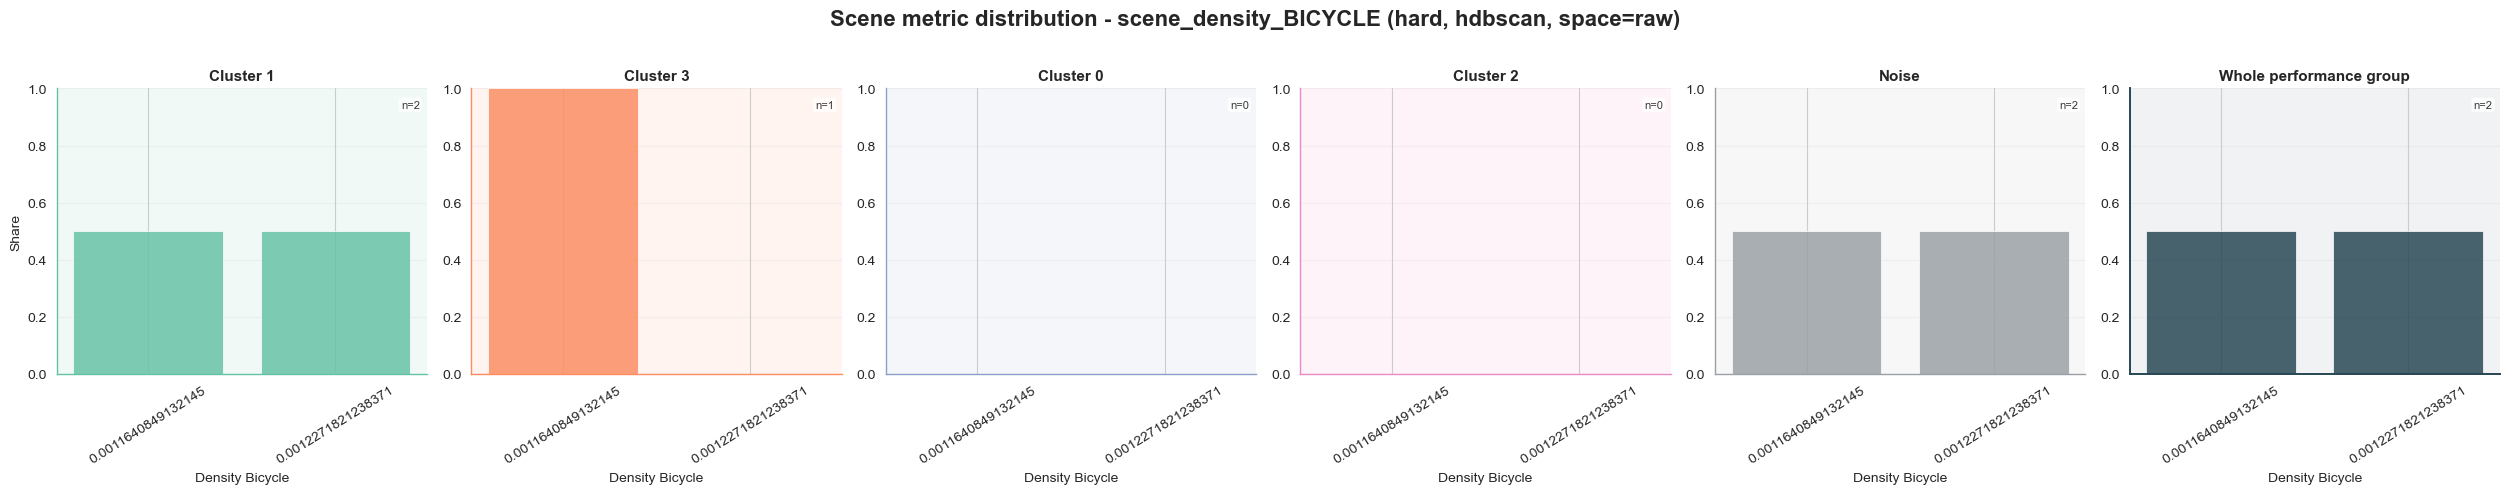

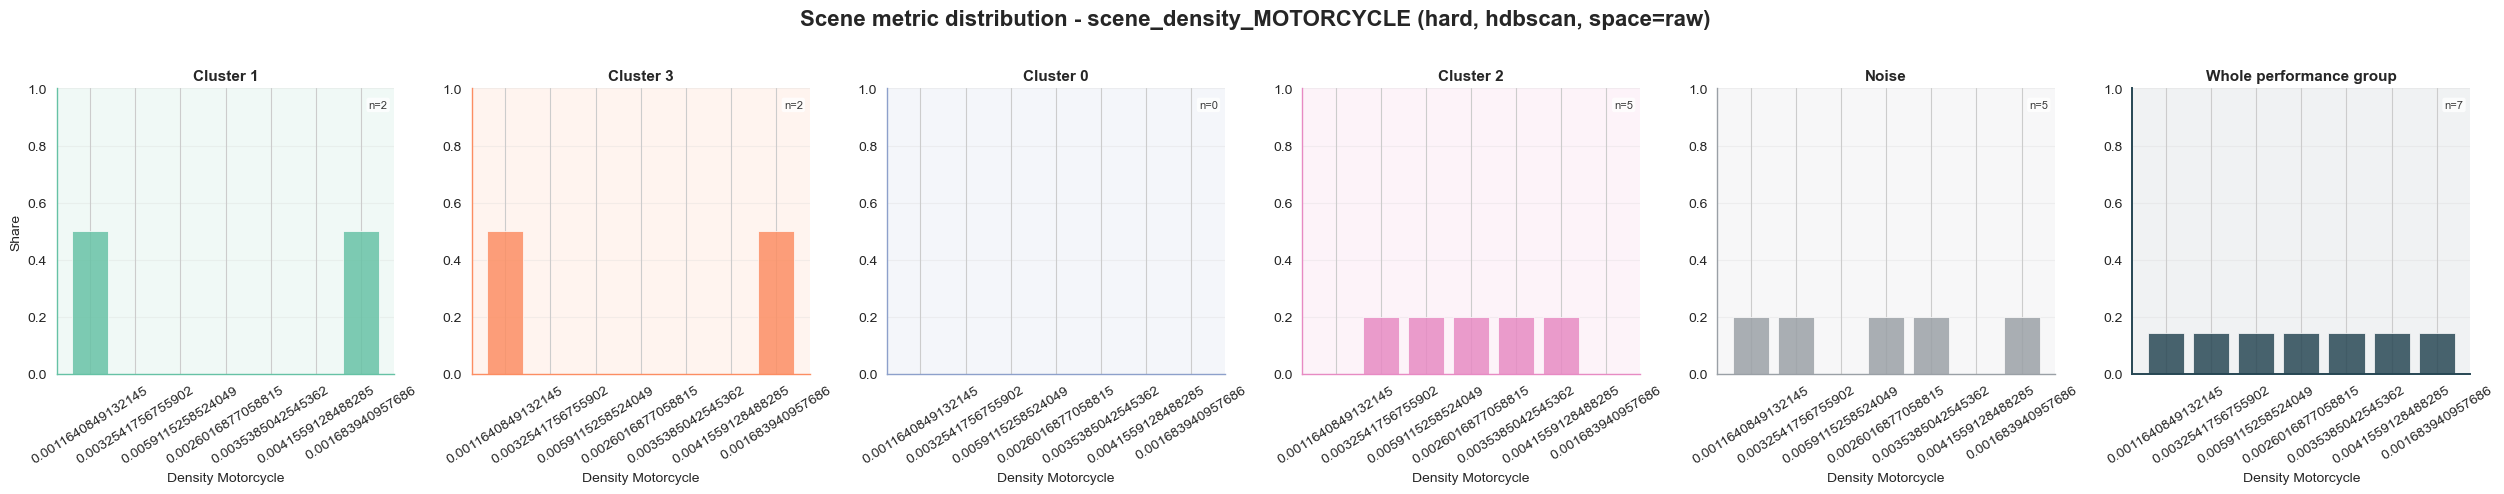

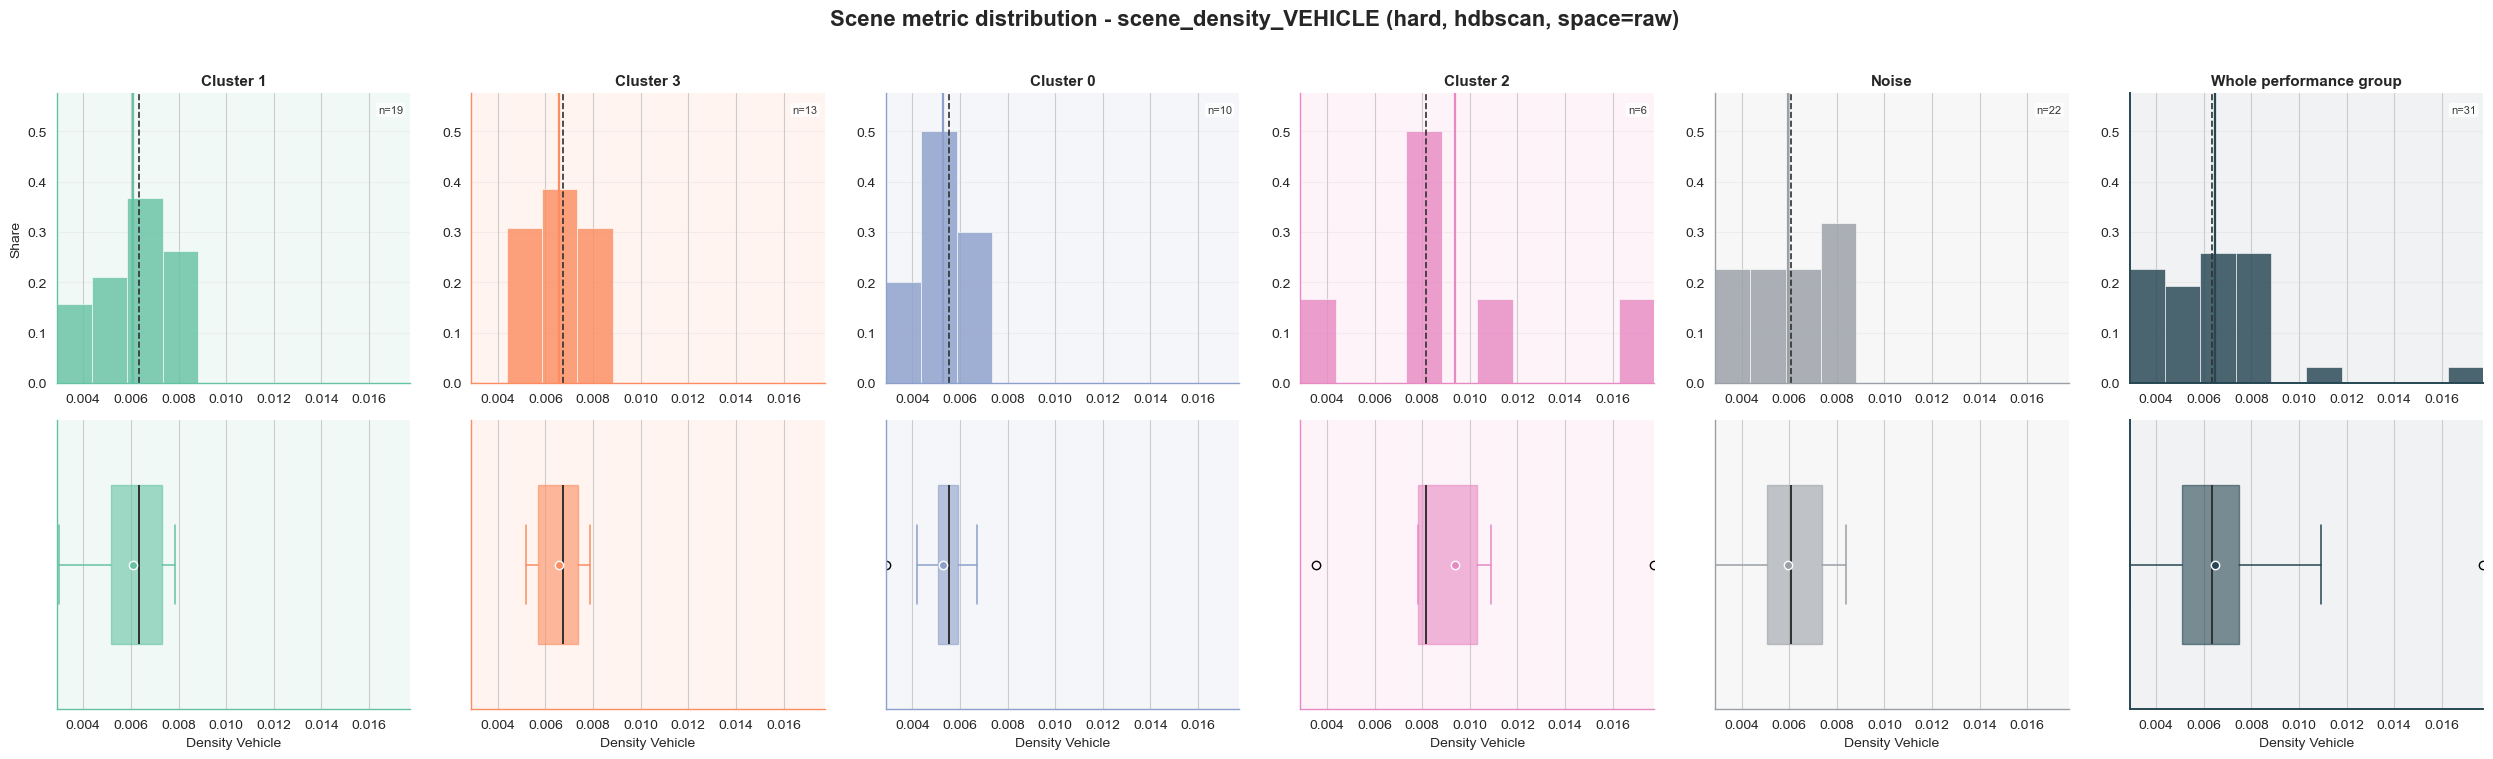

Scene metric distribution plots saved: 13
First scene metric plot: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/shap_performance_regimes/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__space-raw__selection-all/plots/scene_metric_distributions/scene_metric_distribution__scene_num_agents.png


In [17]:
scene_subset_frames = build_distribution_subset_frames(inspection_bundle, scene_level=True)
scene_plot_paths = []

if not inspection_bundle.scene_metric_cols:
    print('No scene_* metric columns were found in the exported assignment table.')
else:
    for metric_col in inspection_bundle.scene_metric_cols:
        plot_path = SCENE_DISTRIBUTION_DIR / f'scene_metric_distribution__{slugify_token(metric_col)}.png'
        plot_metric_distribution_panels(
            scene_subset_frames,
            metric_col=metric_col,
            plot_title=(
                f"Scene metric distribution - {metric_col} "
                f"({inspection_bundle.performance_group}, {inspection_bundle.algorithm}, space={inspection_bundle.cluster_space})"
            ),
            plot_path=plot_path,
            subset_style_map=subset_style_map,
        )
        scene_plot_paths.append(plot_path)

print(f'Scene metric distribution plots saved: {len(scene_plot_paths)}')
if scene_plot_paths:
    print(f'First scene metric plot: {scene_plot_paths[0]}')


## Plot Trajectory-Feature Overview Matrix
**Purpose:** Build compact cluster-by-feature overview matrices for the ordered trajectory characteristics so many features can be scanned quickly at once.<br>
**Inputs:** `trajectory_subset_frames`, the ordered `inspection_bundle.trajectory_feature_cols`, `subset_style_map`, and `INSPECTION_CONFIG['distribution_matrix_max_columns']`.<br>
**Outputs:** One or more paginated trajectory overview matrix figures saved under the dedicated overview output folder.<br>
**How to Verify:** Confirm that rows follow the selected subset order, columns follow the global SHAP-importance order, and additional pages appear only when the feature count exceeds the configured maximum columns.


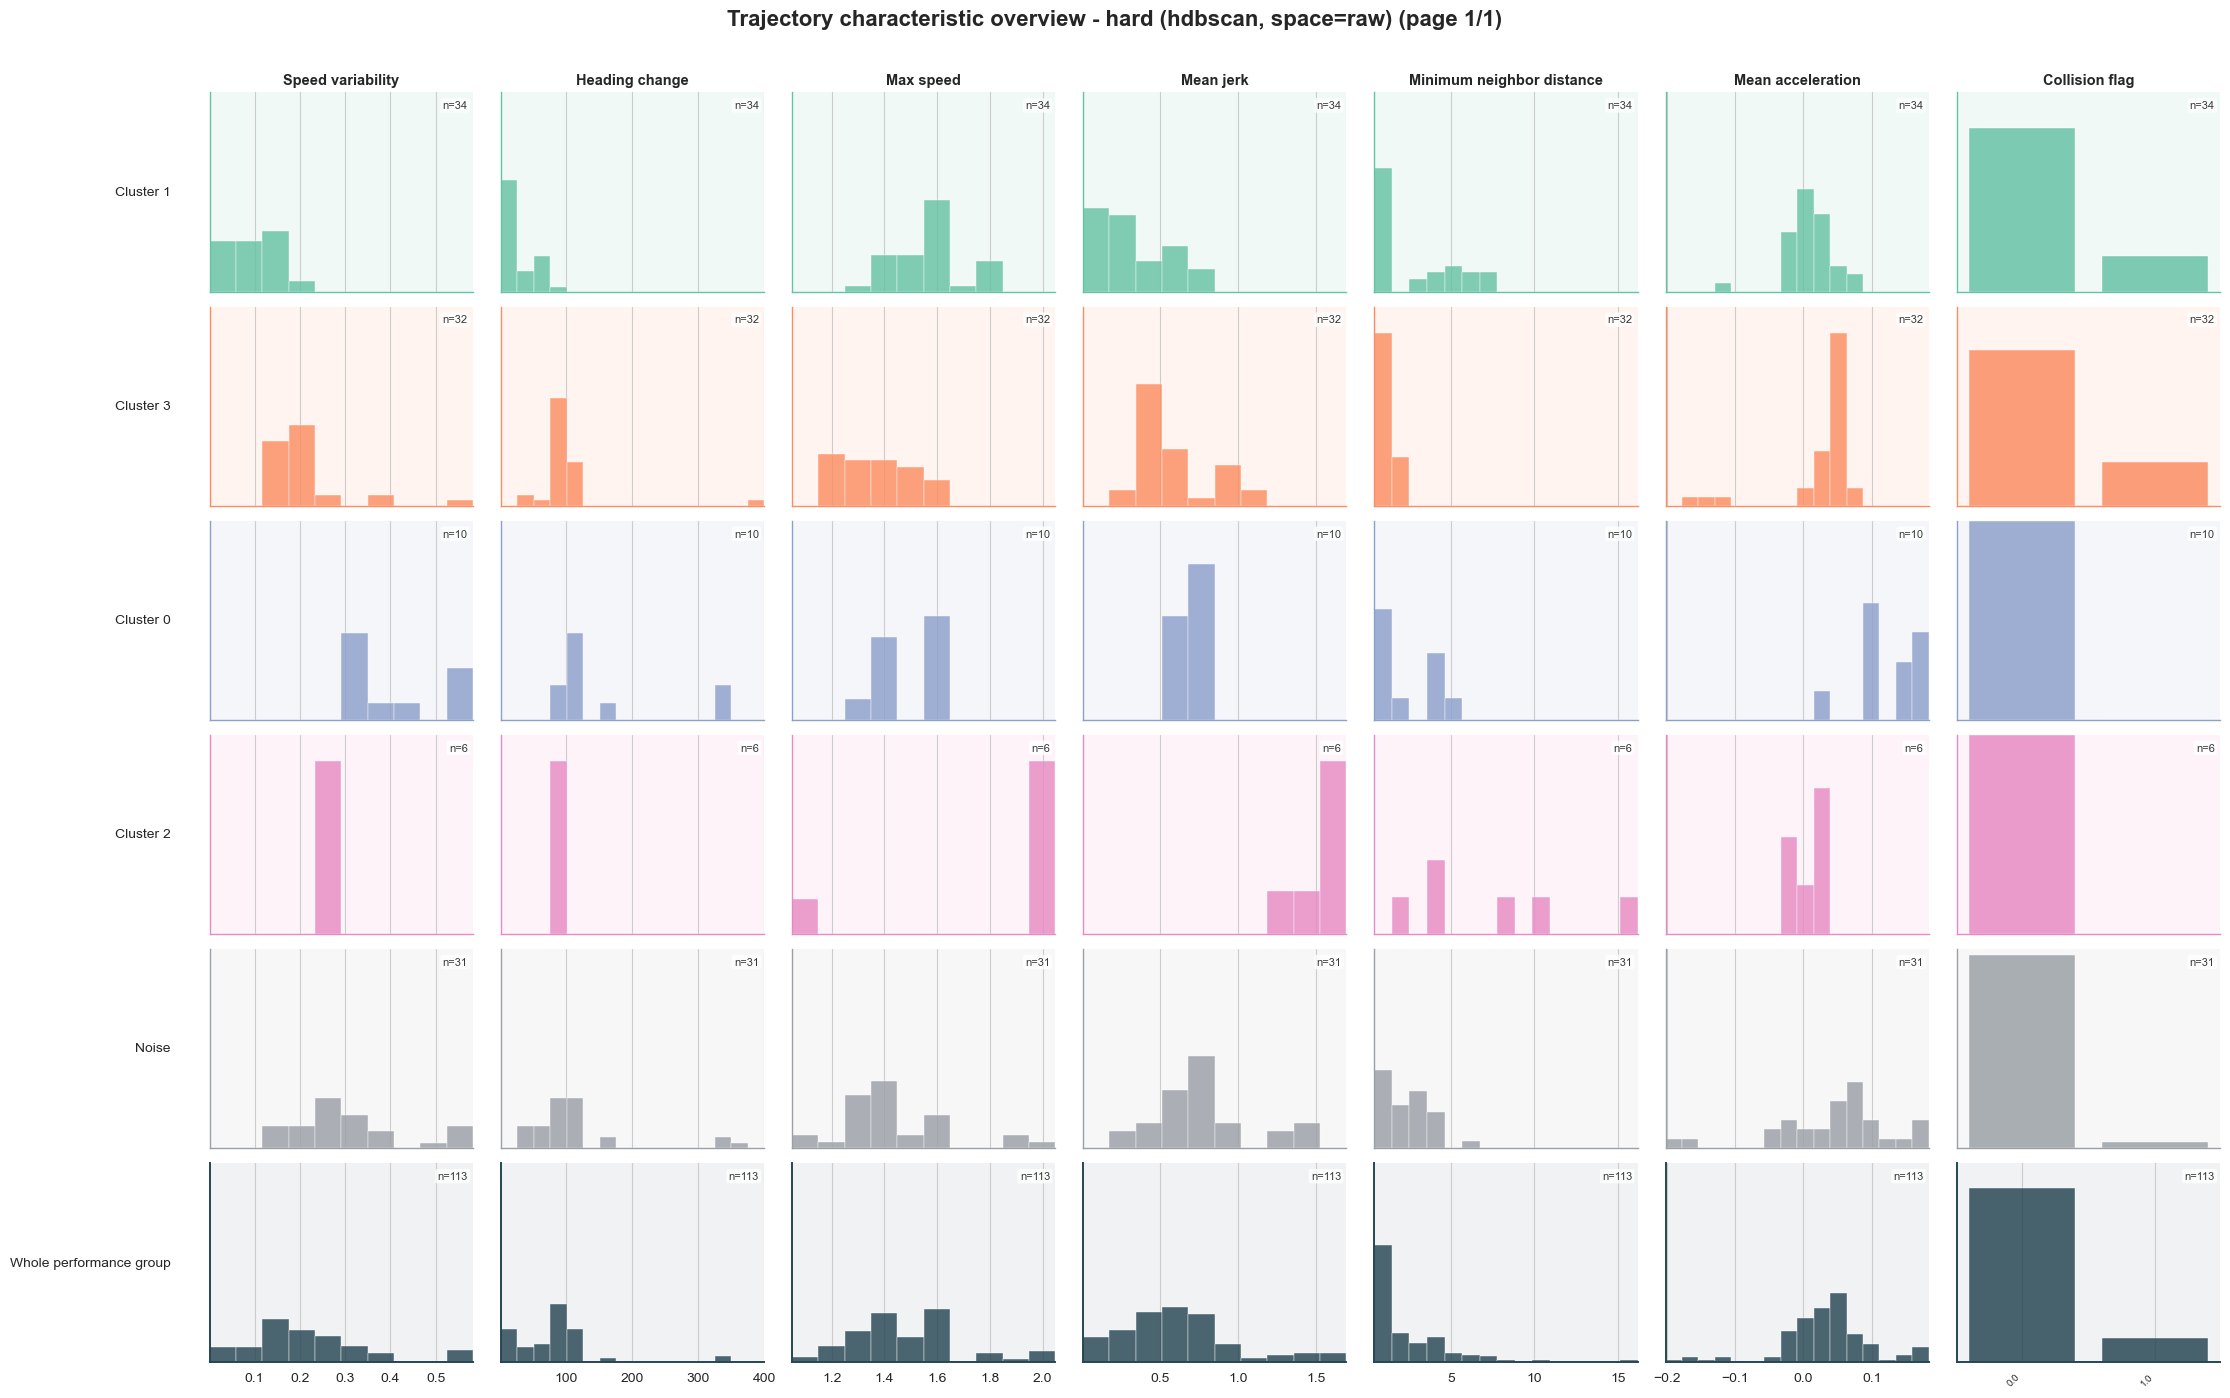

Trajectory overview pages saved: 1
First trajectory overview page: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/shap_performance_regimes/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__space-raw__selection-all/plots/trajectory_feature_overview/trajectory_feature_overview__page-01.png


In [18]:
trajectory_overview_paths = []
if not inspection_bundle.trajectory_feature_cols:
    print('Skipped trajectory overview matrices because no trajectory features were available.')
else:
    trajectory_overview_paths = plot_metric_overview_matrix_pages(
        trajectory_subset_frames,
        metric_cols=inspection_bundle.trajectory_feature_cols,
        plot_title_prefix=(
            f"Trajectory characteristic overview - {inspection_bundle.performance_group} "
            f"({inspection_bundle.algorithm}, space={inspection_bundle.cluster_space})"
        ),
        output_dir=TRAJECTORY_OVERVIEW_DIR,
        output_stem='trajectory_feature_overview',
        subset_style_map=subset_style_map,
        max_columns=resolved_inspection_config['distribution_matrix_max_columns'],
    )
print(f'Trajectory overview pages saved: {len(trajectory_overview_paths)}')
if trajectory_overview_paths:
    print(f'First trajectory overview page: {trajectory_overview_paths[0]}')


## Plot Scene-Characteristic Overview Matrix
**Purpose:** Build compact cluster-by-feature overview matrices for the ordered scene metrics so the cluster scene context can be scanned quickly at once.<br>
**Inputs:** `scene_subset_frames`, the ordered `inspection_bundle.scene_metric_cols`, `subset_style_map`, and `INSPECTION_CONFIG['distribution_matrix_max_columns']`.<br>
**Outputs:** One or more paginated scene overview matrix figures saved under the dedicated overview output folder.<br>
**How to Verify:** Confirm that rows follow the selected subset order, columns follow the semantic scene-metric order with alphabetical fallback, and extra pages appear only when needed.


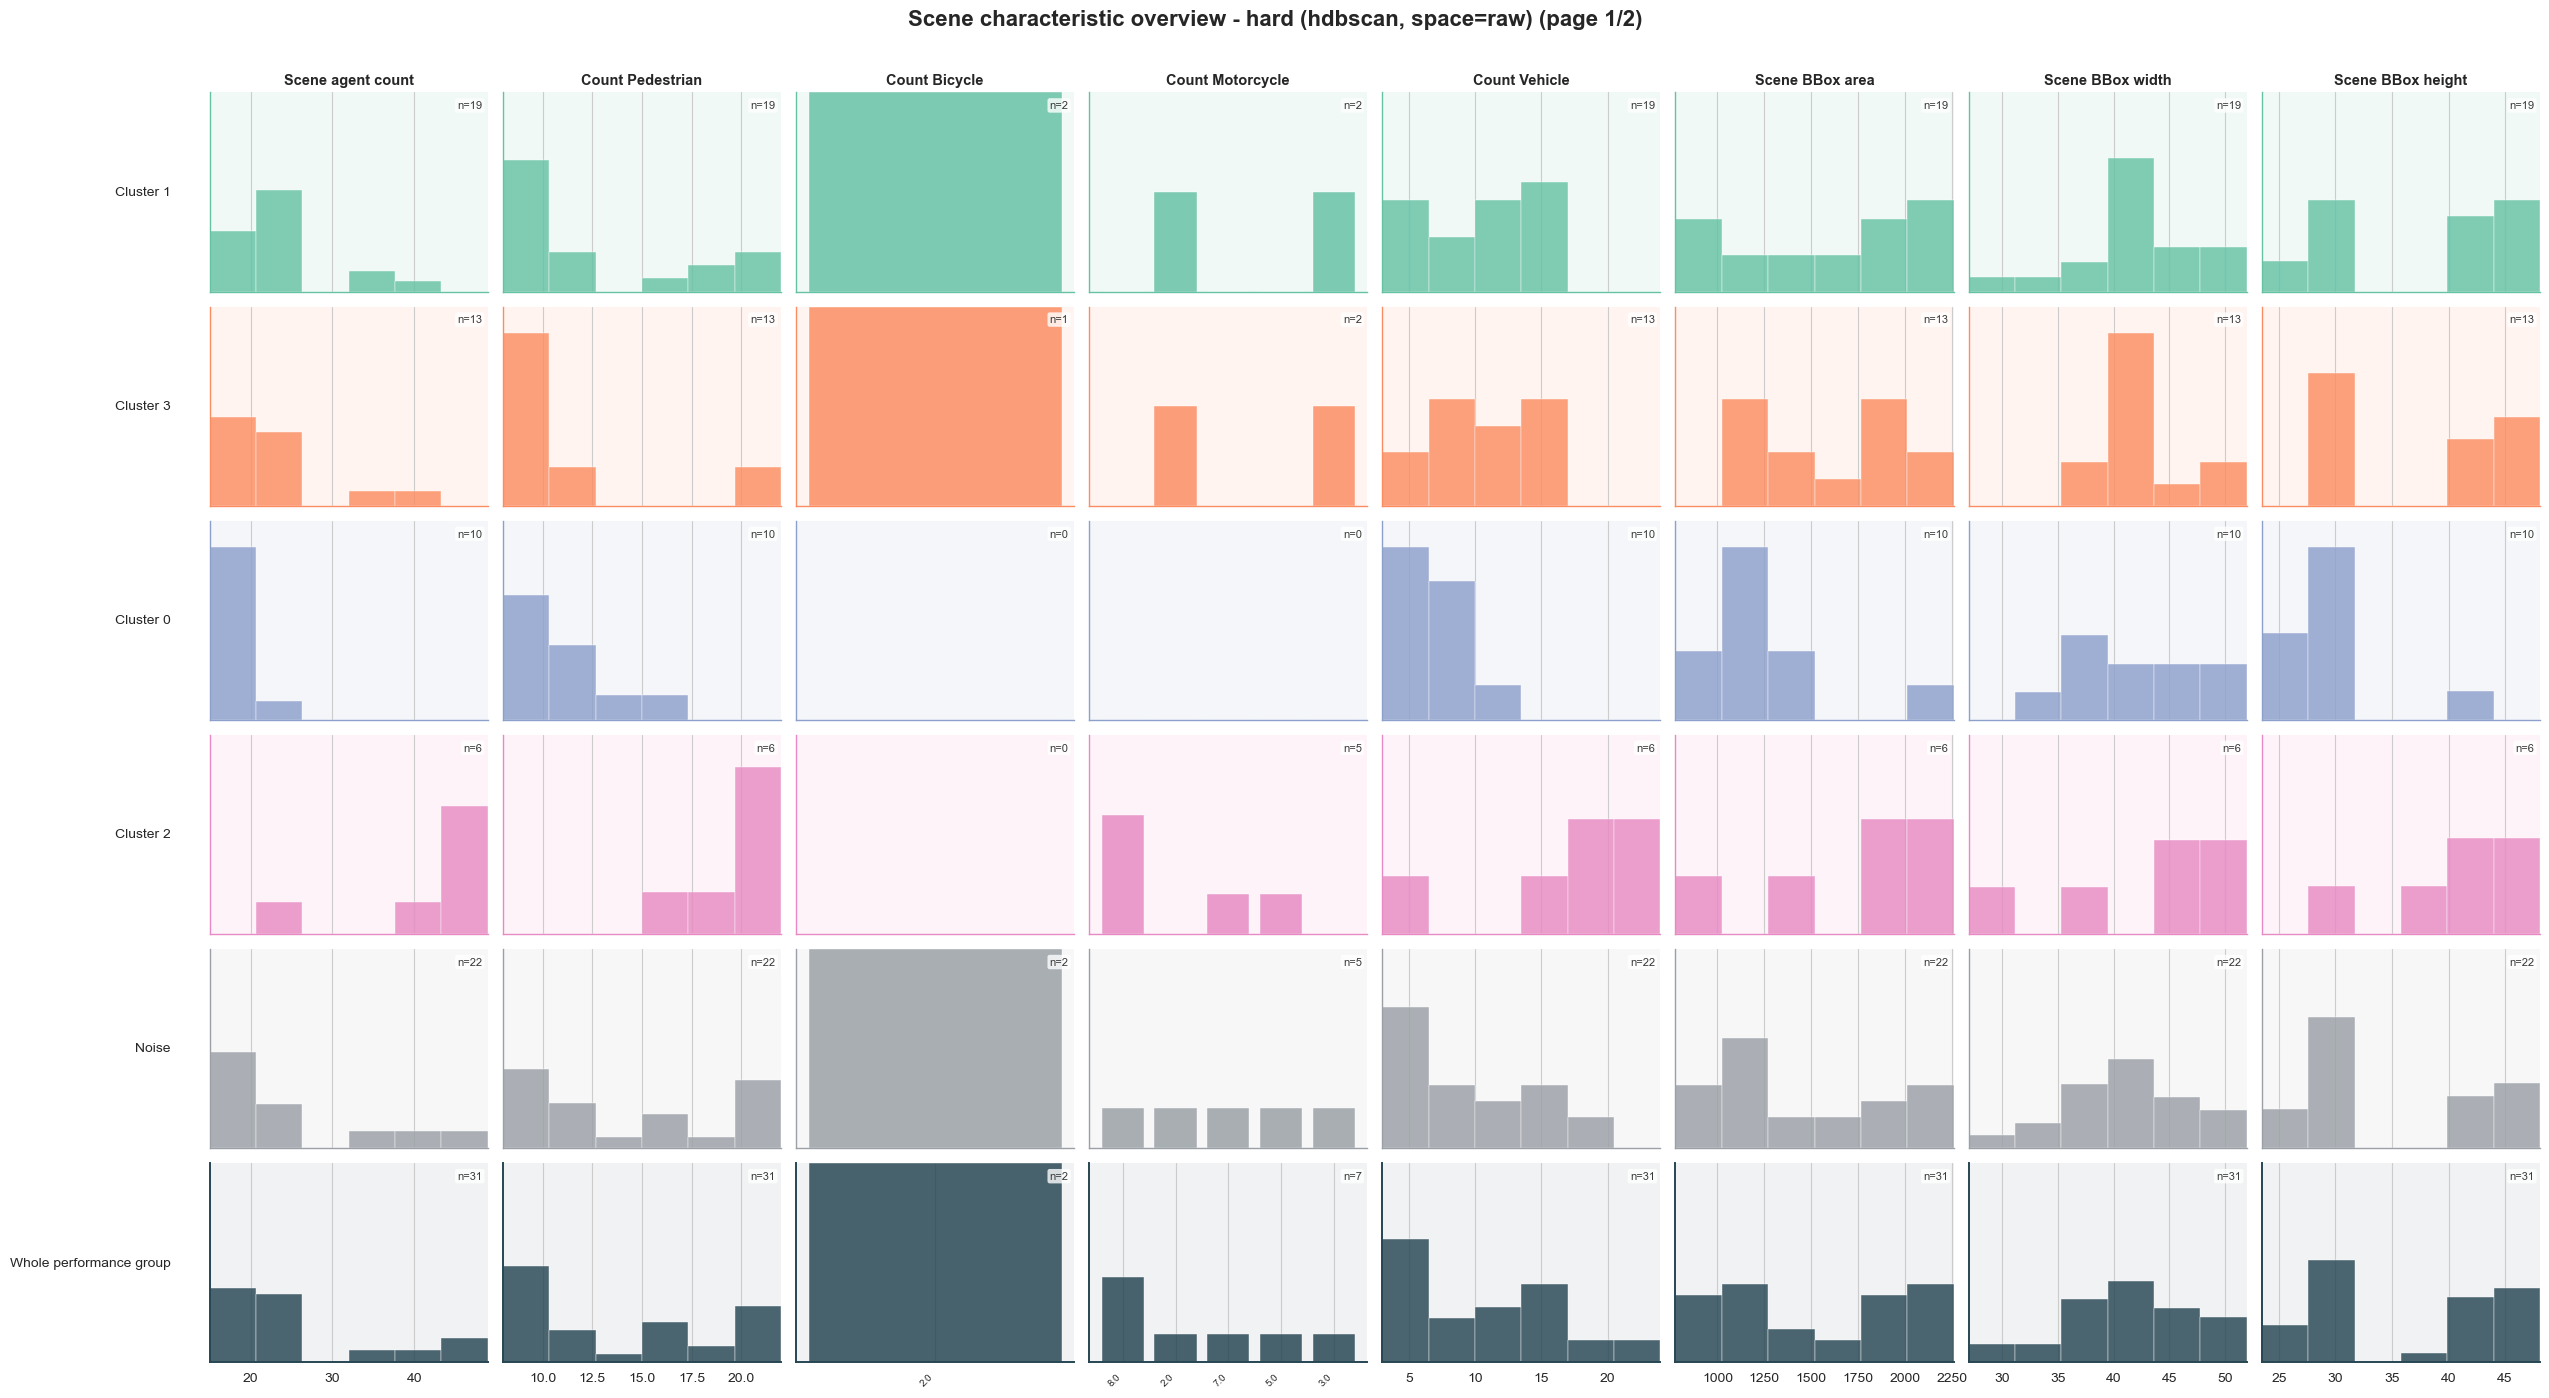

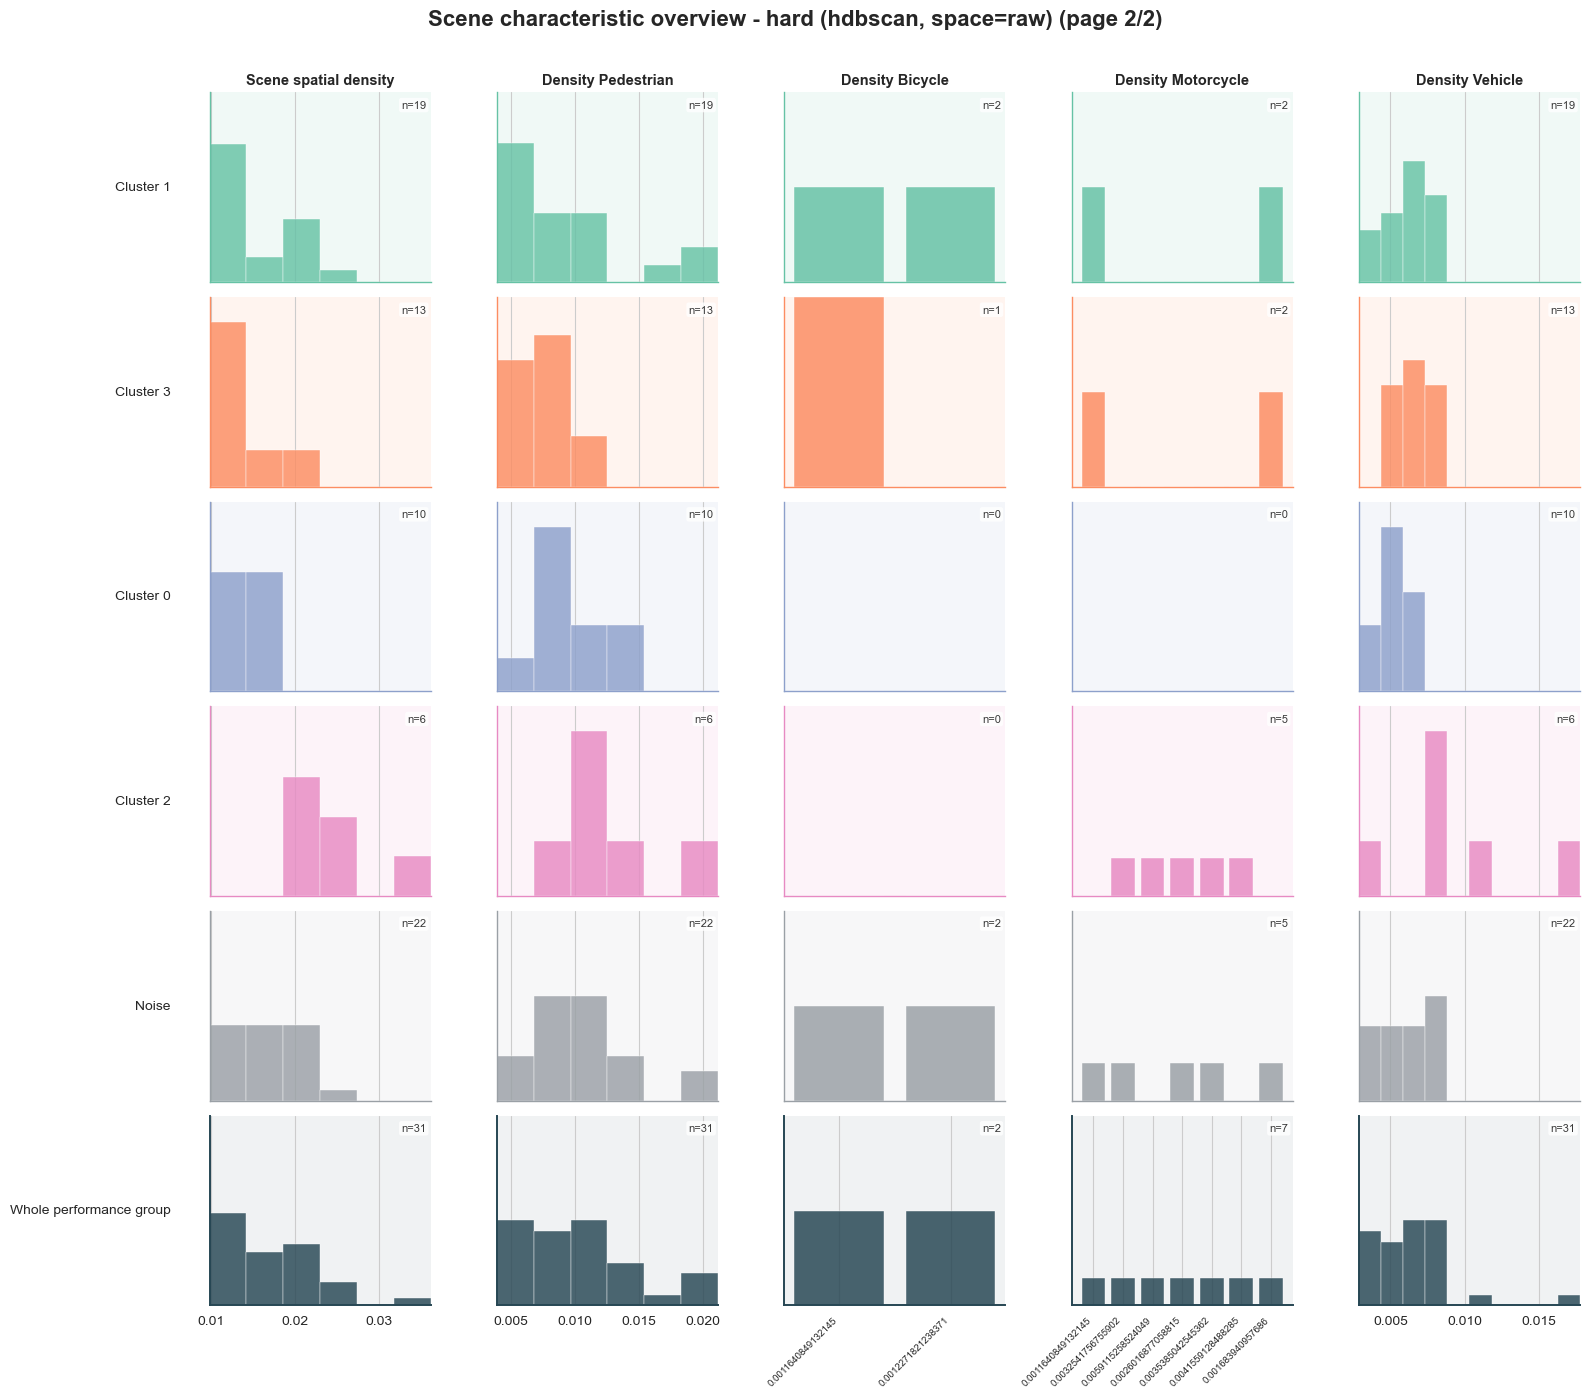

Scene overview pages saved: 2
First scene overview page: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/shap_performance_regimes/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__space-raw__selection-all/plots/scene_metric_overview/scene_metric_overview__page-01.png


In [19]:
scene_overview_paths = []
if not inspection_bundle.scene_metric_cols:
    print('Skipped scene overview matrices because no scene metrics were available.')
else:
    scene_overview_paths = plot_metric_overview_matrix_pages(
        scene_subset_frames,
        metric_cols=inspection_bundle.scene_metric_cols,
        plot_title_prefix=(
            f"Scene characteristic overview - {inspection_bundle.performance_group} "
            f"({inspection_bundle.algorithm}, space={inspection_bundle.cluster_space})"
        ),
        output_dir=SCENE_OVERVIEW_DIR,
        output_stem='scene_metric_overview',
        subset_style_map=subset_style_map,
        max_columns=resolved_inspection_config['distribution_matrix_max_columns'],
    )
print(f'Scene overview pages saved: {len(scene_overview_paths)}')
if scene_overview_paths:
    print(f'First scene overview page: {scene_overview_paths[0]}')


## Review Inspection Outputs
**Purpose:** Summarize where the inspection artifacts were written so the selected candidate can be revisited without rerunning clustering.<br>
**Inputs:** `INSPECTION_LAYOUT`, the saved plot paths from this notebook, and the selected member-file metadata.<br>
**Outputs:** A concise audit trail of the candidate-specific inspection folder and its saved single-feature and overview-matrix plot groups.<br>
**How to Verify:** Check that the reported paths exist under the cluster-spec `inspection/` directory and that the member-file links still point back into `tables/`.


In [20]:
print(f"Inspection selection root: {INSPECTION_LAYOUT['selection_root']}")
print(f"Plots directory: {PLOTS_DIR}")
print(f"Trajectory distribution directory: {TRAJECTORY_DISTRIBUTION_DIR}")
print(f"Scene distribution directory: {SCENE_DISTRIBUTION_DIR}")
print(f"Trajectory overview directory: {TRAJECTORY_OVERVIEW_DIR}")
print(f"Scene overview directory: {SCENE_OVERVIEW_DIR}")
print(f"Selected member files: {len(inspection_bundle.selected_catalog_df)}")
print(f"Trajectory single-feature plots: {len(trajectory_plot_paths)}")
print(f"Scene single-feature plots: {len(scene_plot_paths)}")
print(f"Trajectory overview pages: {len(trajectory_overview_paths)}")
print(f"Scene overview pages: {len(scene_overview_paths)}")
display(inspection_bundle.selected_catalog_df[['cluster_label', 'members_relative_path']])


Inspection selection root: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/shap_performance_regimes/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__space-raw__selection-all
Plots directory: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/shap_performance_regimes/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137/inspection/group-hard__alg-hdbscan__space-raw__selection-all/plots
Trajectory distribution directory: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/

,cluster_label,members_relative_path
0,cluster_1,tables/cluster_members__group-hard__alg-hdbsca...
1,cluster_3,tables/cluster_members__group-hard__alg-hdbsca...
2,cluster_0,tables/cluster_members__group-hard__alg-hdbsca...
3,cluster_2,tables/cluster_members__group-hard__alg-hdbsca...
4,noise,tables/cluster_members__group-hard__alg-hdbsca...
